# Project 8 — Liquidity-Aware Portfolio Rebalancing


## 1. Setup & data load

In [4]:
# ==================================================
# Credential cell: asks for username and password
# ==================================================

import os
from getpass import getpass

username = input("DeepMM username: ")
password = getpass("DeepMM password: ")

os.environ["DEEPMM_USERNAME"] = username
os.environ["DEEPMM_PASSWORD"] = password

# DeepMM dev/internship defaults
os.environ["DEEPMM_REGION"] = "us-west-2"
os.environ["DEEPMM_CLIENT_ID"] = "1hpqr0c8pbiiufsb8n95414jjh"
os.environ["DEEP_MM_SERVER"] = "wss://staging1.deepmm.com"

print("DeepMM credentials loaded into environment variables.")
print("Username loaded:", os.environ.get("DEEPMM_USERNAME") is not None)
print("Password loaded:", os.environ.get("DEEPMM_PASSWORD") is not None)
print("Region:", os.environ.get("DEEPMM_REGION"))
print("Server:", os.environ.get("DEEP_MM_SERVER"))

# ==================================================
# 2. Credentials
# ==================================================
# Option A: type credentials directly here for this notebook session.
# Do NOT commit this notebook if you type credentials here.

os.environ["DEEPMM_USERNAME"] = "YOUR_USERNAME_HERE"
os.environ["DEEPMM_PASSWORD"] = "YOUR_PASSWORD_HERE"


DeepMM credentials loaded into environment variables.
Username loaded: True
Password loaded: True
Region: us-west-2
Server: wss://staging1.deepmm.com


In [13]:
# ==================================================
# Credential cell: asks for username and password
# ==================================================

import os
from getpass import getpass

username = input("DeepMM username: ")
password = getpass("DeepMM password: ")

os.environ["DEEPMM_USERNAME"] = username
os.environ["DEEPMM_PASSWORD"] = password

# DeepMM dev/internship defaults
os.environ["DEEPMM_REGION"] = "us-west-2"
os.environ["DEEPMM_CLIENT_ID"] = "1hpqr0c8pbiiufsb8n95414jjh"
os.environ["DEEP_MM_SERVER"] = "wss://staging1.deepmm.com"

print("DeepMM credentials loaded into environment variables.")
print("Username loaded:", os.environ.get("DEEPMM_USERNAME") is not None)
print("Password loaded:", os.environ.get("DEEPMM_PASSWORD") is not None)
print("Region:", os.environ.get("DEEPMM_REGION"))
print("Server:", os.environ.get("DEEP_MM_SERVER"))

# ==================================================
# 2. Credentials
# ==================================================
# Option A: type credentials directly here for this notebook session.
# Do NOT commit this notebook if you type credentials here.

os.environ["DEEPMM_USERNAME"] = "YOUR_USERNAME_HERE"
os.environ["DEEPMM_PASSWORD"] = "YOUR_PASSWORD_HERE"


DeepMM credentials loaded into environment variables.
Username loaded: True
Password loaded: True
Region: us-west-2
Server: wss://staging1.deepmm.com


In [18]:
import os
import sys
import getpass
import s3fs
import pandas as pd

print("Python executable:", sys.executable)

# Re-input AWS credentials in the CURRENT notebook kernel
AWS_ACCESS_KEY_ID = getpass.getpass("Enter AWS Access Key ID: ")
AWS_SECRET_ACCESS_KEY = getpass.getpass("Enter AWS Secret Access Key: ")
AWS_DEFAULT_REGION = "us-west-2"

# Save into current Python process environment
os.environ["AWS_ACCESS_KEY_ID"] = AWS_ACCESS_KEY_ID
os.environ["AWS_SECRET_ACCESS_KEY"] = AWS_SECRET_ACCESS_KEY
os.environ["AWS_DEFAULT_REGION"] = AWS_DEFAULT_REGION

print("AWS_ACCESS_KEY_ID exists:", bool(os.getenv("AWS_ACCESS_KEY_ID")))
print("AWS_SECRET_ACCESS_KEY exists:", bool(os.getenv("AWS_SECRET_ACCESS_KEY")))
print("AWS_DEFAULT_REGION:", os.getenv("AWS_DEFAULT_REGION"))

print("Access key masked:", AWS_ACCESS_KEY_ID[:4] + "..." + AWS_ACCESS_KEY_ID[-4:])
print("Secret key masked:", AWS_SECRET_ACCESS_KEY[:4] + "..." + AWS_SECRET_ACCESS_KEY[-4:])

Python executable: /opt/miniconda3/bin/python
AWS_ACCESS_KEY_ID exists: True
AWS_SECRET_ACCESS_KEY exists: True
AWS_DEFAULT_REGION: us-west-2
Access key masked: AKIA...CJMF
Secret key masked: 3yvX...cheB


In [19]:
import os
import boto3

print("AWS_ACCESS_KEY_ID exists:", bool(os.getenv("AWS_ACCESS_KEY_ID")))
print("AWS_SECRET_ACCESS_KEY exists:", bool(os.getenv("AWS_SECRET_ACCESS_KEY")))
print("AWS_DEFAULT_REGION:", os.getenv("AWS_DEFAULT_REGION"))

access_key = os.getenv("AWS_ACCESS_KEY_ID")
print("Access Key ID:", access_key[:4] + "..." + access_key[-4:] if access_key else None)

try:
    sts = boto3.client("sts")
    print(sts.get_caller_identity())
except Exception as e:
    print("AWS credential check failed:")
    print(type(e).__name__, e)

AWS_ACCESS_KEY_ID exists: True
AWS_SECRET_ACCESS_KEY exists: True
AWS_DEFAULT_REGION: us-west-2
Access Key ID: AKIA...CJMF
AWS credential check failed:
ClientError An error occurred (IncompleteSignature) when calling the GetCallerIdentity operation: Invalid key=value pair (missing equal-sign) in Authorization header (hashed with SHA-256 and encoded with Base64): 'NFTTFDYpsQYBhls5DXkOo3+05piWEy7nAvhJ4pi8r4o='.


In [16]:
PRICE_PATHS = [
    "deepmm.share/sample_data/trades/atlas_ladder_oos/price_2023_q1_atlas_oos_2023-04-01_2023-06-30.csv.gz",
    "deepmm.share/sample_data/trades/atlas_ladder_oos/price_2023_q2_atlas_oos_2023-07-01_2023-09-30.csv.gz",
    "deepmm.share/sample_data/trades/atlas_ladder_oos/price_2023_q3_atlas_oos_2023-10-01_2023-12-31.csv.gz",
    "deepmm.share/sample_data/trades/atlas_ladder_oos/price_2023_q4_atlas_oos_2024-01-01_2024-03-31.csv.gz",
    "deepmm.share/sample_data/trades/atlas_ladder_oos/price_2024_q1_atlas_oos_2024-04-01_2024-06-30.csv.gz",
    "deepmm.share/sample_data/trades/atlas_ladder_oos/price_2024_q2_atlas_oos_2024-07-01_2024-09-30.csv.gz",
]

KEEP_COLS = ["cusip", "figi", "execution_date", "price", "50_tile", "95_tile", "5_tile"]

atlas_frames = []
for path in PRICE_PATHS:
    quarter = path.split("price_")[1][:7]
    print(f"  Loading {quarter}...", end=" ")
    with fs.open(path, "rb") as f:
        df = pd.read_csv(gzip.GzipFile(fileobj=f), usecols=KEEP_COLS)
    print(f"{len(df):,} rows")
    atlas_frames.append(df)

atlas = pd.concat(atlas_frames, ignore_index=True)
atlas["date"] = pd.to_datetime(atlas["execution_date"], unit="ns").dt.date
atlas["P_TRACE"] = atlas["price"]
atlas["P_AXOR"]  = atlas["50_tile"]
atlas["L_AXOR"]  = atlas["95_tile"] - atlas["5_tile"]
atlas = atlas.drop(columns=["execution_date","price","50_tile","95_tile","5_tile"])

print(f"\nTotal rows: {len(atlas):,}")
print(f"Date range: {atlas['date'].min()} to {atlas['date'].max()}")
print(f"Unique bonds: {atlas['cusip'].nunique():,}")

  Loading 2023_q1... 

ProfileNotFound: The config profile (default) could not be found

In [ ]:
atlas_daily = (
    atlas.groupby(["cusip", "date"])
    .agg(
        P_TRACE=("P_TRACE", "mean"),
        P_AXOR=("P_AXOR",  "mean"),
        L_AXOR=("L_AXOR",  "mean"),
        n_trades=("P_TRACE", "count")
    )
    .reset_index()
)
atlas_daily["date"] = pd.to_datetime(atlas_daily["date"])
print(atlas_daily.shape)
print(f"Date range: {atlas_daily['date'].min()} to {atlas_daily['date'].max()}")
print(f"Unique bonds: {atlas_daily['cusip'].nunique()}")

(3929503, 6)
Date range: 2023-04-03 00:00:00 to 2024-09-27 00:00:00
Unique bonds: 24791


In [ ]:
bcq_files_all = fs.ls("deepmm.data/bondcliq/")

# filter to extended date range Apr 2023 to Sep 2024
bcq_files_extended = [
    f for f in bcq_files_all
    if "pretrade_0803_" in f
    and "20230403" <= f[-12:-4] <= "20240927"
]
print(f"BCQ files to load: {len(bcq_files_extended)}")

coupon_frames = []
bcq_daily_frames = []
for i, path in enumerate(bcq_files_extended):
    try:
        with fs.open(path, "rb") as f:
            raw = f.read()
        z = zipfile.ZipFile(io.BytesIO(raw))
        with z.open(z.namelist()[0]) as zf:
            df = pd.read_csv(zf, header=0, names=[
                "col0","side","record_id","cusip","col4",
                "maturity","coupon","description","price",
                "col9","col10","date","time","col13","col14"
            ])

        # aggregate immediately to save memory
        df["price"] = pd.to_numeric(df["price"], errors="coerce")
        df = df.dropna(subset=["price","cusip","date"])
        coupon_frames.append(df[["cusip", "coupon"]].copy())
        df["date"] = pd.to_datetime(df["date"])

        bids   = df[df["side"]==0].groupby(["cusip","date"])["price"].mean().rename("avg_bid")
        offers = df[df["side"]==1].groupby(["cusip","date"])["price"].mean().rename("avg_offer")
        daily  = pd.concat([bids, offers], axis=1).reset_index().dropna()
        daily["P_BCQ"] = (daily["avg_bid"] + daily["avg_offer"]) / 2
        daily["L_BCQ"] = daily["avg_offer"] - daily["avg_bid"]
        daily = daily[(daily["L_BCQ"] > 0) & (daily["L_BCQ"] < 10)]

        bcq_daily_frames.append(daily[["cusip","date","P_BCQ","L_BCQ"]])

        del df, bids, offers, daily, raw

        if (i+1) % 20 == 0:
            print(f"  processed {i+1}/{len(bcq_files_extended)}")

    except Exception as e:
        print(f"  skipped {path[-20:]}: {e}")
bcq_daily = pd.concat(bcq_daily_frames, ignore_index=True)
print(f"\nBCQ daily panel: {bcq_daily.shape}")
print(f"Date range: {bcq_daily['date'].min().date()} to {bcq_daily['date'].max().date()}")
print(f"Unique bonds: {bcq_daily['cusip'].nunique():,}")


BCQ files to load: 109
  processed 20/109
  processed 40/109
  processed 60/109
  processed 80/109
  processed 100/109

BCQ daily panel: (1211205, 4)
Date range: 2023-04-18 to 2024-04-15
Unique bonds: 25,580


## 2. Build Panel + L_TRACE_MRR

In [ ]:
bcq_daily["date"] = pd.to_datetime(bcq_daily["date"])

panel = atlas_daily.merge(bcq_daily[["cusip","date","P_BCQ","L_BCQ"]],
                           on=["cusip","date"], how="left")

panel = panel.sort_values(["cusip","date"]).reset_index(drop=True)
panel["next_price"] = panel.groupby("cusip")["P_TRACE"].shift(-1)
panel["next_date"]  = panel.groupby("cusip")["date"].shift(-1)
# clean-price return; cell 8 adds coupon accrual on top to get total return
panel["next_return"] = panel["next_price"] / panel["P_TRACE"] - 1
panel = panel.dropna(subset=["next_return"])

panel["L_AXOR_pct"] = panel["L_AXOR"] / panel["P_TRACE"]
panel["L_BCQ_pct"]  = panel["L_BCQ"]  / panel["P_TRACE"]

print(f"Panel shape: {panel.shape}")
print(f"Date range: {panel['date'].min().date()} to {panel['date'].max().date()}")
print(f"Unique bonds: {panel['cusip'].nunique():,}")

Panel shape: (3904712, 13)
Date range: 2023-04-03 to 2024-09-26
Unique bonds: 24,148


In [ ]:
from bond_portfolio_milp import extract_coupon_from_bcq

coupon_all = pd.concat(coupon_frames, ignore_index=True)
coupon_by_cusip = extract_coupon_from_bcq(coupon_all)
panel = panel.merge(coupon_by_cusip, on="cusip", how="left")
print(f"Coupon coverage: {panel['coupon_rate'].notna().mean():.1%}")

# FIX 8 — score on TOTAL return, not clean price.
# next_return is a clean-price change, so charging transaction costs against it
# subtracts a total-return cost from a price-only return. Coupon income here is
# ~1.8 bps/day against ~1.7 bps/day of cost, which is enough on its own to flip
# net P&L negative. next_total_return accrues coupon over exactly the interval
# the price return spans.
from bond_portfolio_milp import add_carry_return, RETURN_COL

panel = add_carry_return(panel)

_carry = panel["carry_return"]
_tot   = panel[RETURN_COL]
print(f"\nFIX 8 — total return = price return + coupon accrual")
print(f"  mean carry            : {_carry.mean()*1e4:6.3f} bps per step "
      f"({_carry.mean()*252*1e2:.2f}%/yr at 252 steps)")
print(f"  mean price return     : {panel['next_return'].mean()*1e4:6.3f} bps per step")
print(f"  mean total return     : {_tot.mean()*1e4:6.3f} bps per step")
print(f"  coupon imputed (median) for {panel['coupon_rate_imputed'].mean():.1%} of rows")
print(f"  mean accrual interval : {panel['accrual_days'].mean():.2f} calendar days")


Coupon coverage: 94.9%

FIX 8 — total return = price return + coupon accrual
  mean carry            :  3.471 bps per step (8.75%/yr at 252 steps)
  mean price return     :  2.743 bps per step
  mean total return     :  6.214 bps per step
  coupon imputed (median) for 5.1% of rows
  mean accrual interval : 2.57 calendar days


In [ ]:
# compute trade counts for MRR eligibility filter
trade_counts = atlas.groupby("cusip")["P_TRACE"].count()

active_cusips = trade_counts[trade_counts >= 100].index
atlas_mrr = atlas[atlas["cusip"].isin(active_cusips)].copy()

def compute_mrr_for_bond(g, window=100, min_periods=30):
    g = g.sort_values("date").copy()
    g["future_price_change_1"] = g["P_TRACE"].shift(-1) - g["P_TRACE"]
    g["price_change"] = g["P_TRACE"].diff()
    g["sign_t"] = np.sign(g["price_change"]).replace(0, np.nan).ffill()
    g["sign_t_plus_1"] = g["sign_t"].shift(-1)
    g["signed_impact"] = g["sign_t"] * g["future_price_change_1"]
    g["R1"] = g["signed_impact"].rolling(window=window, min_periods=min_periods).mean()
    g["C1"] = g["sign_t"].rolling(window=window, min_periods=min_periods).corr(g["sign_t_plus_1"]).clip(-0.99, 0.99)
    g["s_MRR"] = 2 * g["R1"].abs() / (1 - g["C1"])
    return g[["cusip","date","s_MRR"]].dropna(subset=["s_MRR"])

print("Computing MRR in chunks...")
mrr_daily_frames = []
chunk = []
CHUNK_SIZE = 1000

for i, (cusip, g) in enumerate(atlas_mrr.groupby("cusip")):
    chunk.append(compute_mrr_for_bond(g))

    if len(chunk) >= CHUNK_SIZE:
        chunk_df = pd.concat(chunk, ignore_index=True)
        daily_chunk = (
            chunk_df.groupby(["cusip","date"])["s_MRR"]
            .median()
            .reset_index()
            .rename(columns={"s_MRR": "L_TRACE_MRR"})
        )
        mrr_daily_frames.append(daily_chunk)
        chunk = []
        print(f"  {i+1}/{len(active_cusips)} bonds done")

if chunk:
    chunk_df = pd.concat(chunk, ignore_index=True)
    daily_chunk = (
        chunk_df.groupby(["cusip","date"])["s_MRR"]
        .median()
        .reset_index()
        .rename(columns={"s_MRR": "L_TRACE_MRR"})
    )
    mrr_daily_frames.append(daily_chunk)

mrr_daily = pd.concat(mrr_daily_frames, ignore_index=True)
mrr_daily["date"] = pd.to_datetime(mrr_daily["date"])

panel = panel.merge(mrr_daily, on=["cusip","date"], how="left")
print(f"L_TRACE_MRR NaN rate: {panel['L_TRACE_MRR'].isna().mean():.1%}")
print(f"Panel shape: {panel.shape}")

Computing MRR in chunks...
  1000/17099 bonds done
  2000/17099 bonds done
  3000/17099 bonds done
  4000/17099 bonds done
  5000/17099 bonds done
  6000/17099 bonds done
  7000/17099 bonds done
  8000/17099 bonds done
  9000/17099 bonds done
  10000/17099 bonds done
  11000/17099 bonds done
  12000/17099 bonds done
  13000/17099 bonds done
  14000/17099 bonds done
  15000/17099 bonds done
  16000/17099 bonds done
  17000/17099 bonds done
L_TRACE_MRR NaN rate: 6.4%
Panel shape: (3904712, 19)


## 3. Pricing accuracy: AXOR vs BCQ vs realized TRACE

In [ ]:
panel["axor_error"] = (panel["P_AXOR"] - panel["P_TRACE"]).abs() / panel["P_TRACE"]
panel["bcq_error"]  = (panel["P_BCQ"]  - panel["P_TRACE"]).abs() / panel["P_TRACE"]

accuracy_table = pd.DataFrame({
    "Source": ["AXOR (model)", "BondCliQ (dealer quotes)"],
    "Coverage (bond-days)": [panel["axor_error"].notna().sum(), panel["bcq_error"].notna().sum()],
    "Median error vs realized": [panel["axor_error"].median(), panel["bcq_error"].median()],
})
print(accuracy_table.to_string(index=False))


                  Source  Coverage (bond-days)  Median error vs realized
            AXOR (model)               3904712                  0.000832
BondCliQ (dealer quotes)                569646                  0.001855


## 4. Backtest function (ranking signal separated from cost estimate)

In [ ]:
def run_backtest(panel, liquidity_col, top_k=5, ann_factor=252):
    """Daily top-k backtest. Cost always uses L_BCQ_pct, falling back to L_AXOR_pct."""
    df = panel.dropna(subset=[liquidity_col, "next_return", "P_TRACE"]).copy()

    q01 = df["next_return"].quantile(0.01)
    q99 = df["next_return"].quantile(0.99)
    df["next_return"] = df["next_return"].clip(q01, q99)
    df["cost_est"] = df["L_BCQ_pct"].fillna(df["L_AXOR_pct"])

    df["rank"] = df.groupby("date")[liquidity_col].rank(method="first", ascending=True)
    port = df[df["rank"] <= top_k].copy()
    port["weight"] = 1 / port.groupby("date")["cusip"].transform("count")

    w = port.pivot_table(index="date", columns="cusip", values="weight", fill_value=0).sort_index()
    r = port.pivot_table(index="date", columns="cusip", values="next_return").reindex_like(w)
    c = port.pivot_table(index="date", columns="cusip", values="cost_est").reindex_like(w)
    c = c.apply(lambda x: x.fillna(x.median()))

    turnover = w.diff().abs()
    turnover.iloc[0] = w.iloc[0].abs()
    tc = (turnover * c / 2).sum(axis=1)

    gross = (w * r).sum(axis=1)
    net = gross - tc

    def sharpe(s):
        s = s.dropna()
        return np.sqrt(ann_factor) * s.mean() / s.std() if s.std() > 0 else np.nan

    return {
        "liquidity_input": liquidity_col,
        "gross_sharpe": sharpe(gross), "net_sharpe": sharpe(net),
        "total_gross_return": (1 + gross).prod() - 1,
        "total_net_return": (1 + net).prod() - 1,
        "total_txn_cost": tc.sum(),
        "avg_turnover": turnover.sum(axis=1).mean(),
        "n_periods": len(gross),
    }, {"gross": gross, "net": net, "tc": tc}


def run_weekly_backtest(weekly_panel, liquidity_col, top_k=5, ann_factor=52):
    df = weekly_panel.dropna(subset=[liquidity_col, "next_weekly_return", "P_TRACE"]).copy()
    q01 = df["next_weekly_return"].quantile(0.01)
    q99 = df["next_weekly_return"].quantile(0.99)
    df["next_weekly_return"] = df["next_weekly_return"].clip(q01, q99)

    if "L_BCQ_pct" not in df.columns:
        df["L_BCQ_pct"] = df["L_BCQ"] / df["P_TRACE"]
    if "L_AXOR_pct" not in df.columns:
        df["L_AXOR_pct"] = df["L_AXOR"] / df["P_TRACE"]
    df["cost_est"] = df["L_BCQ_pct"].fillna(df["L_AXOR_pct"])

    df["rank"] = df.groupby("week")[liquidity_col].rank(method="first", ascending=True)
    port = df[df["rank"] <= top_k].copy()
    port["weight"] = 1 / port.groupby("week")["cusip"].transform("count")

    w = port.pivot_table(index="week_date", columns="cusip", values="weight", fill_value=0).sort_index()
    r = port.pivot_table(index="week_date", columns="cusip", values="next_weekly_return").reindex_like(w)
    c = port.pivot_table(index="week_date", columns="cusip", values="cost_est").reindex_like(w)
    c = c.apply(lambda x: x.fillna(x.median()) if x.notna().any() else x.fillna(0))

    turnover = w.diff().abs()
    turnover.iloc[0] = w.iloc[0].abs()
    tc = (turnover * c / 2).sum(axis=1)

    gross = (w * r).sum(axis=1)
    net = gross - tc

    def sharpe(s, periods):
        s = s.dropna()
        return np.sqrt(periods) * s.mean() / s.std() if s.std() > 0 else np.nan

    return {
        "liquidity_input": liquidity_col,
        "gross_sharpe": sharpe(gross, ann_factor), "net_sharpe": sharpe(net, ann_factor),
        "total_gross_return": (1 + gross).prod() - 1,
        "total_net_return": (1 + net).prod() - 1,
        "total_txn_cost": tc.sum(),
        "avg_weekly_turnover": turnover.sum(axis=1).mean(),
        "n_weeks": len(gross),
    }, {"gross": gross, "net": net, "tc": tc}


=== DAILY COMPARISON TABLE ===
                 gross_sharpe  net_sharpe  total_gross_return  total_net_return  total_txn_cost  avg_turnover  n_periods
liquidity_input                                                                                                         
L_TRACE_MRR            0.3664    -23.6110              0.0332           -0.9387          2.8130        1.8654        373
L_BCQ                 -1.4761     -2.2221             -0.0202           -0.0305          0.0105        1.7429        105
L_AXOR                 1.1743     -4.2766              0.0125           -0.1756          0.2048        1.5298        373


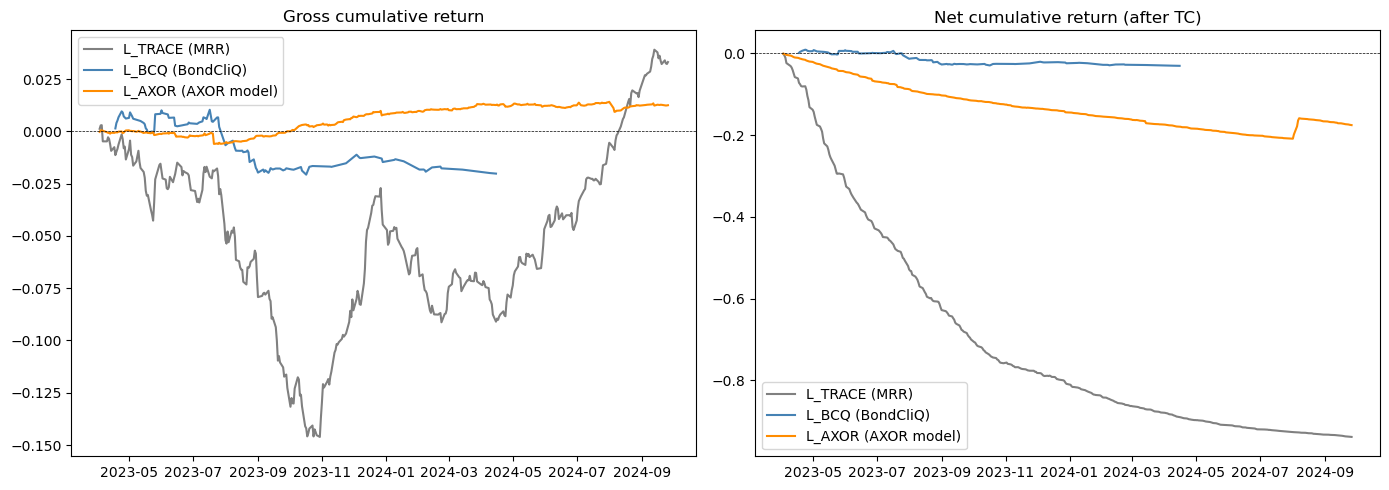

In [ ]:
results, returns = [], {}
for col in ["L_TRACE_MRR", "L_BCQ", "L_AXOR"]:
    summary, ret = run_backtest(panel, col, top_k=5)
    results.append(summary)
    returns[col] = ret

comparison = pd.DataFrame(results).set_index("liquidity_input").round(4)
print("=== DAILY COMPARISON TABLE ===")
print(comparison.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"L_TRACE_MRR": "gray", "L_BCQ": "steelblue", "L_AXOR": "darkorange"}
labels = {"L_TRACE_MRR": "L_TRACE (MRR)", "L_BCQ": "L_BCQ (BondCliQ)", "L_AXOR": "L_AXOR (AXOR model)"}

for col, ret in returns.items():
    cum_gross = (1 + ret["gross"]).cumprod() - 1
    cum_net   = (1 + ret["net"]).cumprod() - 1
    axes[0].plot(cum_gross.index, cum_gross.values, label=labels[col], color=colors[col])
    axes[1].plot(cum_net.index,   cum_net.values,   label=labels[col], color=colors[col])

axes[0].set_title("Gross cumulative return")
axes[1].set_title("Net cumulative return (after TC)")
for ax in axes:
    ax.legend()
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

## 5. Tracking error vs equal-weight benchmark

Benchmark gross Sharpe: 1.1797
                 annualized_alpha  tracking_error  information_ratio
liquidity_input                                                     
L_TRACE_MRR               -0.0021          0.0403            -0.0530
L_BCQ                      0.0045          0.0401             0.1112
L_AXOR                    -0.0031          0.0491            -0.0638


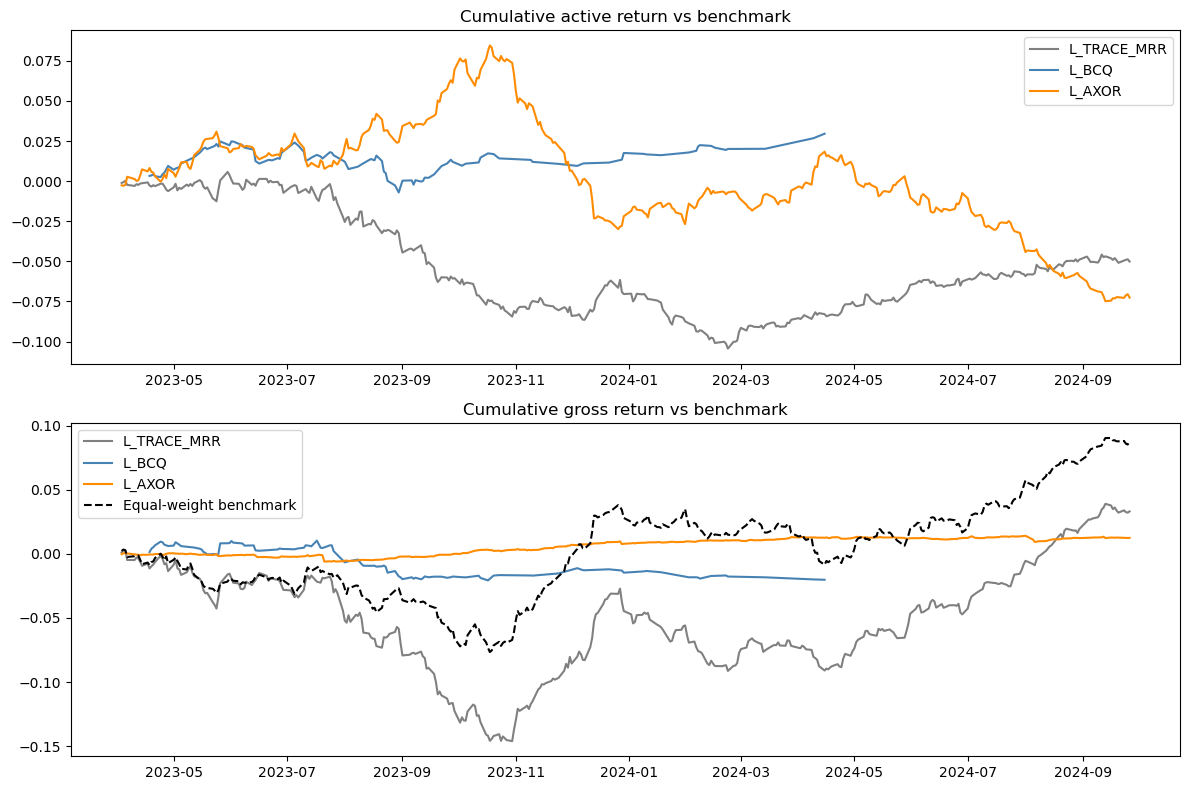

In [ ]:
bm = panel.dropna(subset=["next_return"]).copy()
q01, q99 = bm["next_return"].quantile([0.01, 0.99])
bm["next_return"] = bm["next_return"].clip(q01, q99)
benchmark = bm.groupby("date")["next_return"].mean()
benchmark.index = pd.to_datetime(benchmark.index)

print(f"Benchmark gross Sharpe: {np.sqrt(252) * benchmark.mean() / benchmark.std():.4f}")

te_results = []
for col, ret in returns.items():
    port = ret["gross"]
    port.index = pd.to_datetime(port.index)
    common = port.index.intersection(benchmark.index)
    active = port.loc[common] - benchmark.loc[common]
    ann_alpha = np.sqrt(252) * active.mean()
    ann_te = np.sqrt(252) * active.std()
    te_results.append({
        "liquidity_input": col,
        "annualized_alpha": round(ann_alpha, 4),
        "tracking_error": round(ann_te, 4),
        "information_ratio": round(ann_alpha / ann_te, 4) if ann_te > 0 else np.nan,
    })

print(pd.DataFrame(te_results).set_index("liquidity_input").to_string())

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
colors = {"L_TRACE_MRR": "gray", "L_BCQ": "steelblue", "L_AXOR": "darkorange"}

for col, ret in returns.items():
    port = ret["gross"]
    port.index = pd.to_datetime(port.index)
    common = port.index.intersection(benchmark.index)
    active = port.loc[common] - benchmark.loc[common]
    cum_active = (1 + active).cumprod() - 1
    axes[0].plot(cum_active.index, cum_active.values, label=col, color=colors[col])
    axes[1].plot(port.loc[common].index, (1 + port.loc[common]).cumprod() - 1,
                 label=col, color=colors[col])

bm_cum = (1 + benchmark).cumprod() - 1
axes[1].plot(bm_cum.index, bm_cum.values, label="Equal-weight benchmark",
             color="black", linestyle="--")
axes[0].set_title("Cumulative active return vs benchmark"); axes[0].legend()
axes[1].set_title("Cumulative gross return vs benchmark"); axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Trade-list stability (Jaccard similarity)

L_TRACE_MRR: mean Jaccard = 0.0377
L_BCQ: mean Jaccard = 0.0759
L_AXOR: mean Jaccard = 0.1450


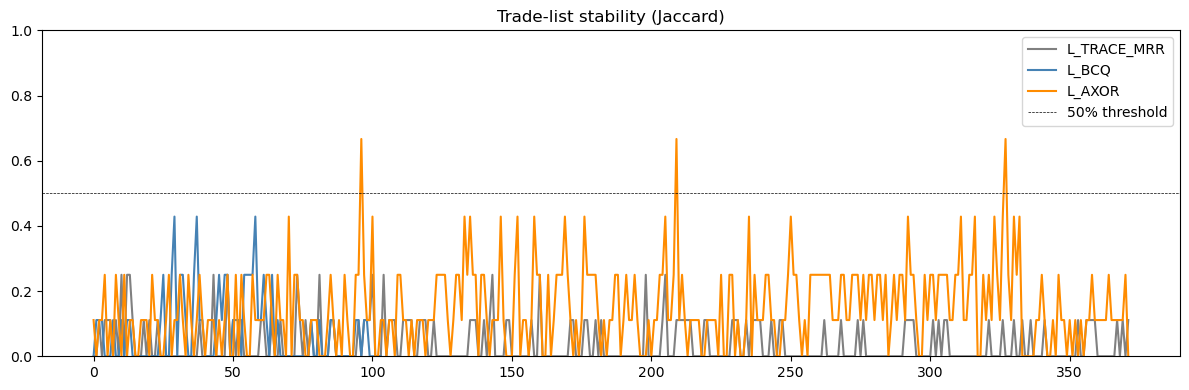

In [ ]:
def jaccard_stability(panel, liquidity_col, top_k=5):
    df = panel.dropna(subset=[liquidity_col, "next_return"]).copy()
    df["rank"] = df.groupby("date")[liquidity_col].rank(method="first", ascending=True)
    port = df[df["rank"] <= top_k].copy()
    daily_baskets = port.groupby("date")["cusip"].apply(set).reset_index().sort_values("date")
    sims = []
    for i in range(1, len(daily_baskets)):
        a, b = daily_baskets.iloc[i-1]["cusip"], daily_baskets.iloc[i]["cusip"]
        sims.append(len(a & b) / len(a | b))
    return pd.Series(sims), np.mean(sims)

for col in ["L_TRACE_MRR", "L_BCQ", "L_AXOR"]:
    _, mean_j = jaccard_stability(panel, col)
    print(f"{col}: mean Jaccard = {mean_j:.4f}")

fig, ax = plt.subplots(figsize=(12, 4))
colors = {"L_TRACE_MRR": "gray", "L_BCQ": "steelblue", "L_AXOR": "darkorange"}
for col in ["L_TRACE_MRR", "L_BCQ", "L_AXOR"]:
    series, _ = jaccard_stability(panel, col)
    ax.plot(range(len(series)), series.values, label=col, color=colors[col])
ax.axhline(0.5, color="black", linewidth=0.5, linestyle="--", label="50% threshold")
ax.set_title("Trade-list stability (Jaccard)")
ax.legend(); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 8. D2D bid-offer L_AXOR (AXOR API)

**Security note:** set `DEEPMM_USERNAME` / `DEEPMM_PASSWORD` as real environment
variables on your machine (e.g. `export DEEPMM_PASSWORD=...` in your shell profile)
rather than hardcoding them in the notebook. Rotate the password if it was ever
committed to git.



In [ ]:
import os
import json
import asyncio
import gzip
from axor import connect, create_get_id_token
from getpass import getpass

os.environ["DEEPMM_USERNAME"] = input("DeepMM username: ")
os.environ["DEEPMM_PASSWORD"] = getpass("DeepMM password: ")


async def fetch_bid_offer_batch(figi_list, timestamp, ws, get_id_token, batch_size=250):
    results = {}
    for i in range(0, len(figi_list), batch_size):
        batch_figis = figi_list[i:i+batch_size]
        inference_batch = []
        for figi in batch_figis:
            inference_batch.append({"rfq_label": "price", "figi": figi, "quantity": 1_000_000,
                                     "side": "bid", "ats_indicator": "N",
                                     "timestamp": [timestamp], "subscribe": False})
            inference_batch.append({"rfq_label": "price", "figi": figi, "quantity": 1_000_000,
                                     "side": "offer", "ats_indicator": "N",
                                     "timestamp": [timestamp], "subscribe": False})

        await ws.send(json.dumps({"token": get_id_token(), "inference": inference_batch}))
        raw = await ws.recv()
        if isinstance(raw, bytes):
            try:
                raw = gzip.decompress(raw).decode("utf-8")
            except Exception:
                raw = raw.decode("utf-8")
        resp = json.loads(raw)

        for item in resp.get("inference", []):
            figi, side, prices = item.get("figi"), item.get("side"), item.get("price")
            if not prices or figi is None:
                continue
            results.setdefault(figi, {})[side] = prices[9]
        await asyncio.sleep(0.5)

    final = {}
    for figi, sides in results.items():
        if "bid" in sides and "offer" in sides:
            final[figi] = {"bid": sides["bid"], "offer": sides["offer"],
                            "spread": sides["offer"] - sides["bid"],
                            "mid": (sides["bid"] + sides["offer"]) / 2}
    return final


async def build_L_AXOR_d2d(figi_list, dates, max_retries=3):
    get_id_token = create_get_id_token(
        region="us-west-2", client_id="7s1ivc3lskhoqah91onu2tr794",
        username=os.environ["DEEPMM_USERNAME"], password=os.environ["DEEPMM_PASSWORD"]
    )
    ws = await connect("wss://staging1.deepmm.com")
    all_rows = []
    for i, d in enumerate(dates):
        timestamp = pd.Timestamp(d).strftime("%Y-%m-%dT12:00:00.000Z")
        result = {}
        for attempt in range(max_retries):
            try:
                result = await fetch_bid_offer_batch(figi_list, timestamp, ws, get_id_token)
                if result:
                    break
            except Exception:
                await asyncio.sleep(2)
        for figi, vals in result.items():
            all_rows.append({"figi": figi, "date": pd.Timestamp(d), **vals})
        print(f"  {d}: {len(result)} bonds priced ({i+1}/{len(dates)})", end="\r")
    await ws.close()
    out = pd.DataFrame(all_rows)
    if out.empty:
        out = pd.DataFrame(columns=["figi", "date", "bid", "offer", "spread", "mid"])
    return out



In [ ]:
# top 1400 most-traded bonds with FIGI, all sample dates (Project8_final universe)
D2D_N_BONDS = 1400
cusip_to_figi = (
    atlas[["cusip", "figi"]].dropna().drop_duplicates(subset="cusip")
    .set_index("cusip")["figi"].to_dict()
)
top_cusips = (
    atlas.groupby("cusip")["P_TRACE"].count()
    .sort_values(ascending=False)
    .head(D2D_N_BONDS)
    .index.tolist()
)
top_figi_map = {c: cusip_to_figi[c] for c in top_cusips if c in cusip_to_figi}
dates = sorted(atlas_daily["date"].unique())
print(f"D2D fetch universe: {len(top_figi_map)} bonds (target {D2D_N_BONDS}, with FIGI)")

def _load_saved_d2d():
    print("Using L_AXOR_D2D from panel_project8_extended.parquet (last successful pull)")
    _saved = pd.read_parquet("panel_project8_extended.parquet")
    _need = {"cusip", "date", "L_AXOR_D2D", "P_AXOR_D2D_mid"}
    if not _need.issubset(_saved.columns) or not _saved["L_AXOR_D2D"].notna().any():
        raise RuntimeError(
            "panel_project8_extended.parquet has no L_AXOR_D2D. "
            "Cannot continue Section 8 until staging returns data or a saved panel is present."
        )
    out = (
        _saved.loc[_saved["L_AXOR_D2D"].notna(),
                   ["cusip", "date", "L_AXOR_D2D", "P_AXOR_D2D_mid"]]
        .rename(columns={"L_AXOR_D2D": "spread", "P_AXOR_D2D_mid": "mid"})
        .copy()
    )
    out["figi"] = out["cusip"].map(cusip_to_figi)
    out = out.dropna(subset=["figi"])
    print(f"Final D2D panel (from saved file): {out.shape}, dates: {out['date'].nunique()}/{len(dates)}")
    return out

# Probe a few dates first. A full 374-day pass of 0-bond days is what you just saw;
# staging is connecting but not returning prices.
print(f"Probing live D2D on {min(3, len(dates))} dates...")
_probe = await build_L_AXOR_d2d(list(top_figi_map.values()), dates[:3])
_probe_n = 0 if _probe.empty else int((_probe.get("spread", pd.Series(dtype=float)) > 0).sum())
print(f"Probe rows with positive spread: {_probe_n}")

if _probe_n == 0:
    l_axor_d2d = _load_saved_d2d()
else:
    l_axor_d2d_raw = await build_L_AXOR_d2d(list(top_figi_map.values()), dates)
    print(f"\nRaw D2D rows: {l_axor_d2d_raw.shape}, dates covered: {l_axor_d2d_raw['date'].nunique()}/{len(dates)}")
    missing_dates = sorted(set(pd.Timestamp(d) for d in dates) - set(l_axor_d2d_raw["date"].unique()))
    if missing_dates:
        filled = await build_L_AXOR_d2d(list(top_figi_map.values()), missing_dates)
        l_axor_d2d_raw = pd.concat([l_axor_d2d_raw, filled], ignore_index=True)
    l_axor_d2d = l_axor_d2d_raw[l_axor_d2d_raw["spread"] > 0].copy()
    print(f"Final D2D panel: {l_axor_d2d.shape}, dates: {l_axor_d2d['date'].nunique()}/{len(dates)}")


D2D fetch universe: 1400 bonds (target 1400, with FIGI)
Probing live D2D on 3 dates...
Attempting connection to wss://staging1.deepmm.com
Unsuccessful connection to wss://staging1.deepmm.com
Attempting connection to wss://staging1.deepmm.com
Successful connection to wss://staging1.deepmm.com
Probe rows with positive spread: 1909ed (3/3)
Attempting connection to wss://staging1.deepmm.com
Successful connection to wss://staging1.deepmm.com
  2024-09-27 00:00:00: 0 bonds priced (374/374))
Raw D2D rows: (12055, 6), dates covered: 21/374
Attempting connection to wss://staging1.deepmm.com
Successful connection to wss://staging1.deepmm.com
Final D2D panel: (24305, 6), dates: 42/374/353))


In [ ]:
figi_to_cusip = {v: k for k, v in top_figi_map.items()}
l_axor_d2d["cusip"] = l_axor_d2d["figi"].map(figi_to_cusip)

l_axor_d2d_daily = (
    l_axor_d2d.groupby(["cusip", "date"])
    .agg(L_AXOR_D2D=("spread", "mean"), P_AXOR_D2D_mid=("mid", "mean"))
    .reset_index()
)
# make this cell safe to re-run: drop D2D columns from any earlier merge
panel = panel.drop(columns=[c for c in ["L_AXOR_D2D", "P_AXOR_D2D_mid"] if c in panel.columns])
panel = panel.merge(l_axor_d2d_daily, on=["cusip", "date"], how="left")
print(f"L_AXOR_D2D coverage: {panel['L_AXOR_D2D'].notna().mean():.1%}")
print(f"Bonds with D2D: {panel.loc[panel['L_AXOR_D2D'].notna(), 'cusip'].nunique():,}")

comparison_d2d = panel[["L_AXOR", "L_AXOR_D2D"]].dropna()
print(f"Correlation old vs new L_AXOR: {comparison_d2d['L_AXOR'].corr(comparison_d2d['L_AXOR_D2D']):.3f}")

# persist D2D columns immediately so later reload cells see L_AXOR_D2D
panel.to_parquet("panel_project8_extended.parquet", index=False)
print(f"Saved panel with D2D: {panel.shape}")


L_AXOR_D2D coverage: 0.6%
Bonds with D2D: 1,274
Correlation old vs new L_AXOR: 0.671
Saved panel with D2D: (3904712, 23)


D2D comparison sample: 10002 rows, 1272 bonds

L_AXOR: gross_sharpe=-1.8247, net_sharpe=-6.8094, turnover=1.52
L_AXOR_D2D: gross_sharpe=-2.9797, net_sharpe=-14.1842, turnover=1.72


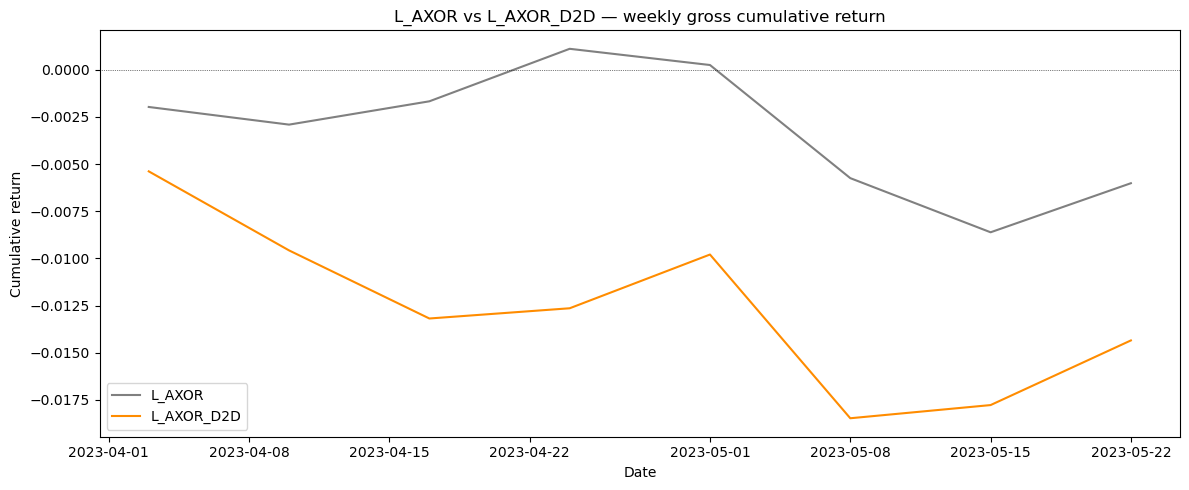

In [ ]:
# weekly backtest: old uncertainty-band L_AXOR vs new D2D bid-offer L_AXOR,
# restricted to bonds where the D2D measure exists
panel_d2d = panel[panel["L_AXOR_D2D"].notna()].copy()
panel_d2d["week"] = pd.to_datetime(panel_d2d["date"]).dt.to_period("W")

weekly_d2d = (
    panel_d2d.sort_values(["cusip", "date"]).groupby(["cusip", "week"]).last().reset_index()
)
weekly_d2d["next_weekly_price"] = weekly_d2d.groupby("cusip")["P_TRACE"].shift(-1)
weekly_d2d["next_weekly_return"] = weekly_d2d["next_weekly_price"] / weekly_d2d["P_TRACE"] - 1
weekly_d2d = weekly_d2d.dropna(subset=["next_weekly_return"])
weekly_d2d["week_date"] = weekly_d2d["week"].dt.start_time

print(f"D2D comparison sample: {weekly_d2d.shape[0]} rows, {weekly_d2d['cusip'].nunique()} bonds\n")
for col in ["L_AXOR", "L_AXOR_D2D"]:
    summary, _ = run_weekly_backtest(weekly_d2d, col, top_k=5)
    print(
        f"{col}: gross_sharpe={summary['gross_sharpe']:.4f}, "
        f"net_sharpe={summary['net_sharpe']:.4f}, turnover={summary['avg_weekly_turnover']:.2f}"
    )

fig, ax = plt.subplots(figsize=(12, 5))
colors = {"L_AXOR": "gray", "L_AXOR_D2D": "darkorange"}
for col in ["L_AXOR", "L_AXOR_D2D"]:
    _, ret = run_weekly_backtest(weekly_d2d, col, top_k=5)
    cum = (1 + ret["gross"]).cumprod() - 1
    ax.plot(cum.index, cum.values, label=col, color=colors[col])

ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax.set_title("L_AXOR vs L_AXOR_D2D — weekly gross cumulative return")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return")
ax.legend()
plt.tight_layout()
plt.show()


## 9. CBonds segment data + segment analysis

**Known limitation:** CBonds covers a broader/more international/structured-product
universe than this AXOR/TRACE corporate bond panel — only ~11% of bonds match across
multiple snapshot dates tested. Segment results below are on that matched subset only;
treat as directional, not representative of the full universe.


In [ ]:
def load_cbonds_day(date_str):
    path = f"deepmm.data/cbonds/{date_str}.zip"
    with fs.open(path, "rb") as f:
        raw = f.read()
    z = zipfile.ZipFile(io.BytesIO(raw))
    with z.open("emissions.csv") as f:
        df = pd.read_csv(f, sep=";", low_memory=False)
    df["cusip"] = df["CUSIP / CUSIP RegS"].astype(str).str.strip().str.upper()
    return df[df["cusip"].str.len() == 9]

# load multiple snapshots and union them for better coverage
cbonds_frames = []
for date_str in ["2023-07-03", "2023-10-02", "2024-01-02", "2024-04-01"]:
    try:
        df = load_cbonds_day(date_str)
        cbonds_frames.append(df)
        print(f"  loaded {date_str}: {df['cusip'].nunique()} bonds")
    except Exception as e:
        print(f"  skipped {date_str}: {e}")

cbonds_all = pd.concat(cbonds_frames, ignore_index=True)

# discover rating column from CBonds export (no placeholder left behind)
from bond_portfolio_milp import RATING_COL_CANDIDATES
_rating_src = next((c for c in RATING_COL_CANDIDATES if c in cbonds_all.columns), None)
if _rating_src is None:
    _rating_src = next((c for c in cbonds_all.columns if "rating" in str(c).lower()), None)
print(f"CBonds rating source column: {_rating_src!r}")

keep = [
    "cusip", "Full name of the issuer (eng)", "Kind (eng)", "Maturity date",
    "Outstanding amount ", "Floating rate (yes/no)", "Subordinated debt (yes/no)",
    "Country of the issuer (eng)",
]
if _rating_src is not None:
    keep.append(_rating_src)

keep = [c for c in keep if c in cbonds_all.columns]
cbonds_clean = cbonds_all[keep].drop_duplicates("cusip").copy()
_rename = [
    "cusip", "issuer_name", "sector", "maturity_date",
    "outstanding_amount", "floating_rate", "subordinated_debt", "country",
]
if _rating_src is not None and _rating_src in keep:
    _rename.append("rating")
cbonds_clean.columns = _rename[: len(keep)]

# make this cell safe to re-run: drop CBonds columns from any earlier merge
_cb_cols = [
    "issuer_name", "sector", "maturity_date", "outstanding_amount",
    "floating_rate", "subordinated_debt", "country", "rating",
]
_stale = [
    c for c in panel.columns
    if c in _cb_cols or (c.endswith(("_x", "_y")) and c[:-2] in _cb_cols)
]
if _stale:
    panel = panel.drop(columns=_stale)

panel = panel.merge(cbonds_clean, on="cusip", how="left")
print(f"\nCBonds match coverage: {panel['issuer_name'].notna().mean():.1%}")
print(f"Unique matched bonds: {panel[panel['issuer_name'].notna()]['cusip'].nunique():,}")
if "rating" in panel.columns:
    print(f"Rating coverage: {panel['rating'].notna().mean():.1%}")
else:
    print("WARNING: no rating column found in CBonds export — HY constraint may be inactive")


  loaded 2023-07-03: 45729 bonds
  loaded 2023-10-02: 45047 bonds
  loaded 2024-01-02: 43668 bonds
  loaded 2024-04-01: 43844 bonds
CBonds rating source column: None

CBonds match coverage: 15.8%
Unique matched bonds: 2,939


In [ ]:
import bond_portfolio_milp as m

if "rating" in panel.columns:
    m.RATING_COL_OVERRIDE = "rating"
    print(f"Rating coverage: {panel['rating'].notna().mean():.1%}")
else:
    m.RATING_COL_OVERRIDE = None
    print("WARNING: panel has no 'rating' column — skip RATING_COL_OVERRIDE")


In [ ]:
panel["maturity_date"] = pd.to_datetime(panel["maturity_date"], errors="coerce")
panel["date"] = pd.to_datetime(panel["date"])
# robust to pandas datetime-unit quirks: divide the timedelta directly
panel["years_to_maturity"] = (panel["maturity_date"] - panel["date"]) / pd.Timedelta(days=365.25)
assert panel["years_to_maturity"].abs().max() > 0.5, "years_to_maturity looks wrong (all ~0) — check date dtypes"

def maturity_bucket(y):
    if pd.isna(y): return "unknown"
    return "short (<3y)" if y < 3 else "medium (3-10y)" if y < 10 else "long (>10y)"

def size_bucket(amt):
    if pd.isna(amt): return "unknown"
    return "small (<250M)" if amt < 250e6 else "medium (250-750M)" if amt < 750e6 else "large (>750M)"

panel["maturity_bucket"] = panel["years_to_maturity"].apply(maturity_bucket)
panel["size_bucket"] = panel["outstanding_amount"].apply(size_bucket)

panel_segment = panel[panel["issuer_name"].notna()].copy()
panel_segment["week"] = pd.to_datetime(panel_segment["date"]).dt.to_period("W")

weekly_segment = (
    panel_segment.sort_values(["cusip","date"]).groupby(["cusip","week"]).last().reset_index()
)
weekly_segment["next_weekly_price"] = weekly_segment.groupby("cusip")["P_TRACE"].shift(-1)
weekly_segment["next_weekly_return"] = weekly_segment["next_weekly_price"] / weekly_segment["P_TRACE"] - 1
weekly_segment = weekly_segment.dropna(subset=["next_weekly_return"])
weekly_segment["week_date"] = weekly_segment["week"].dt.start_time

print(f"Segment sample: {weekly_segment.shape[0]} rows, {weekly_segment['cusip'].nunique()} bonds "
      f"({weekly_segment['cusip'].nunique()/panel['cusip'].nunique():.1%} of full universe)")


Segment sample: 166389 rows, 2884 bonds (11.9% of full universe)


In [ ]:
from bond_portfolio_milp import estimate_modified_duration

panel["duration"] = panel.apply(
    lambda r: estimate_modified_duration(r["P_TRACE"], r["coupon_rate"], r["years_to_maturity"]),
    axis=1,
)

print(f"Duration coverage: {panel['duration'].notna().mean():.1%}")
print(panel["duration"].describe())

Duration coverage: 15.4%
count    602000.000000
mean          5.768535
std           4.869547
min           0.381074
25%           2.379819
50%           3.563055
75%           9.125232
max          21.328567
Name: duration, dtype: float64


In [ ]:
def run_segment_backtest(segment_col, values, min_bonds=10):
    rows = []
    for val in values:
        seg = weekly_segment[weekly_segment[segment_col] == val]
        n_bonds = seg["cusip"].nunique()
        if n_bonds < min_bonds:
            continue
        summary, _ = run_weekly_backtest(seg, "L_AXOR", top_k=5)
        summary["segment"] = val
        summary["n_bonds"] = n_bonds
        rows.append(summary)
    return pd.DataFrame(rows).set_index("segment")

print("=== L_AXOR BY SECTOR ===")
print(run_segment_backtest("sector", weekly_segment["sector"].dropna().unique())
      [["n_bonds","gross_sharpe","net_sharpe","total_net_return"]].to_string())

print("\n=== L_AXOR BY MATURITY ===")
print(run_segment_backtest("maturity_bucket", ["short (<3y)","medium (3-10y)","long (>10y)"])
      [["n_bonds","gross_sharpe","net_sharpe","total_net_return"]].to_string())

print("\n=== L_AXOR BY ISSUE SIZE ===")
print(run_segment_backtest("size_bucket", ["small (<250M)","medium (250-750M)","large (>750M)"])
      [["n_bonds","gross_sharpe","net_sharpe","total_net_return"]].to_string())


=== L_AXOR BY SECTOR ===
                     n_bonds  gross_sharpe  net_sharpe  total_net_return
segment                                                                 
International bonds     2260      2.339252   -1.956001         -0.039900
Domestic bonds           624      1.862264   -2.538574         -0.063058

=== L_AXOR BY MATURITY ===
                n_bonds  gross_sharpe  net_sharpe  total_net_return
segment                                                            
short (<3y)        1352      3.676557   -1.499233         -0.027366
medium (3-10y)     1383      0.166821   -2.987711         -0.151168
long (>10y)         857      0.370547   -2.151148         -0.310680

=== L_AXOR BY ISSUE SIZE ===
                   n_bonds  gross_sharpe  net_sharpe  total_net_return
segment                                                               
small (<250M)          197      0.121707   -3.458737         -0.252271
medium (250-750M)     1467      1.947898   -2.006538         -0.047343
l

## 10. Save panel

In [ ]:
panel.to_parquet("panel_project8_extended.parquet", index=False)
print(f"Saved: {panel.shape}")

Saved: (3904712, 34)


## 8. Freshness Ablation

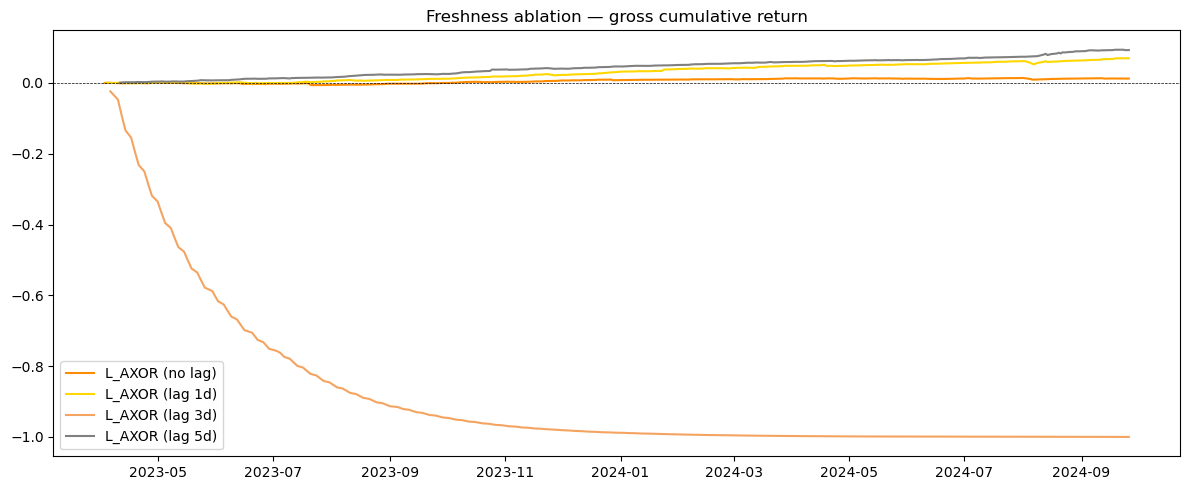

In [ ]:
# freshness ablation using L_AXOR from atlas_daily (5_tile/95_tile no longer available)
# make this cell safe to re-run: drop lag columns from any earlier merge
panel = panel.drop(columns=[c for c in panel.columns
                            if c.startswith("L_AXOR_lag")])
for lag in [1, 3, 5]:
    lagged = atlas_daily[["cusip","date","L_AXOR"]].sort_values(["cusip","date"]).copy()
    lagged["date"] = pd.to_datetime(lagged["date"])
    lagged[f"L_AXOR_lag{lag}"] = lagged.groupby("cusip")["L_AXOR"].shift(lag)
    panel = panel.merge(lagged[["cusip","date",f"L_AXOR_lag{lag}"]], on=["cusip","date"], how="left")

ablation_returns = {}
_, ret = run_backtest(panel, "L_AXOR", top_k=5)
ablation_returns["L_AXOR (no lag)"] = ret
for lag in [1, 3, 5]:
    _, ret = run_backtest(panel, f"L_AXOR_lag{lag}", top_k=5)
    ablation_returns[f"L_AXOR (lag {lag}d)"] = ret

fig, ax = plt.subplots(figsize=(12, 5))
colors = {"L_AXOR (no lag)": "darkorange", "L_AXOR (lag 1d)": "gold",
          "L_AXOR (lag 3d)": "sandybrown", "L_AXOR (lag 5d)": "gray"}
for label, ret in ablation_returns.items():
    cum = (1 + ret["gross"]).cumprod() - 1
    cum.index = pd.to_datetime(cum.index)
    ax.plot(cum.index, cum.values, label=label, color=colors[label])
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_title("Freshness ablation — gross cumulative return")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# MILP freshness ablation (Fix 6) — requires L_AXOR_lag* from the cell above
from bond_portfolio_milp import run_milp_backtest, summarize_backtest

milp_ablation_results = {}
for lag_label, col in [("no lag", "L_AXOR")] + [(f"lag {l}d", f"L_AXOR_lag{l}") for l in [1, 3, 5]]:
    daily_df, gross_s, net_s = run_milp_backtest(panel, col)
    milp_ablation_results[lag_label] = summarize_backtest(daily_df, gross_s, net_s)
    print(lag_label, milp_ablation_results[lag_label])


no lag {'days_solved': 371, 'gross_sharpe': 1.5414580295261322, 'net_sharpe': 0.41975629235507544, 'cum_gross_return': 0.08957919704010497, 'cum_net_return': 0.022825390320407424, 'mean_turnover': 0.09641378464990065, 'mean_predicted_tc': 0.00017043961116356695, 'mean_realized_tc': 0.00020275589553181143, 'total_predicted_tc': 0.06323309574168334, 'total_realized_tc': 0.07522243724230204, 'mean_liq_score': 0.964772482547354, 'mean_duration': 4.0008230394892434, 'mean_hy_weight': 1.0}
lag 1d {'days_solved': 369, 'gross_sharpe': 1.4921027605711839, 'net_sharpe': 0.5484579920107079, 'cum_gross_return': 0.08520093161869546, 'cum_net_return': 0.029978169137125255, 'mean_turnover': 0.0830384087238754, 'mean_predicted_tc': 0.0001415300046796746, 'mean_realized_tc': 0.00017575234615074218, 'total_predicted_tc': 0.05222457172679992, 'total_realized_tc': 0.06485261572962386, 'mean_liq_score': 0.965148988637815, 'mean_duration': 4.00035903436121, 'mean_hy_weight': 1.0}
lag 3d {'days_solved': 367,

## 11. MILP Portfolio Optimizer

In [ ]:
import importlib
import bond_portfolio_milp as _bpm
importlib.reload(_bpm)

from bond_portfolio_milp import (
    POLICY,
    ELIGIBILITY_POLICY,
    apply_eligibility,
    solve_stage_a,
    solve_stage_b,
)

print("Loaded bond_portfolio_milp from:", _bpm.__file__)
print("POLICY keys:", list(POLICY.keys()))
print("ELIGIBILITY_POLICY keys:", list(ELIGIBILITY_POLICY.keys()))

# smoke test on one date
_test_date = panel["date"].dropna().iloc[-1]
_test_day = panel[panel["date"] == _test_date].copy()
_elig = apply_eligibility(_test_day, ELIGIBILITY_POLICY)
print(f"Smoke test date={_test_date.date()}  universe={len(_test_day)}  eligible={len(_elig)}")


Loaded bond_portfolio_milp from: c:\Users\ajhav\OneDrive\Documents\Aryan\Fordham MSQF\Deep Market Making Internship\DeepMM Summer Intern Project Requirements\Assigned Project\bond_portfolio_milp.py
POLICY keys: ['max_weight_single_bond', 'max_weight_single_issuer', 'max_weight_single_sector', 'max_weight_high_yield', 'treat_unknown_rating_as_hy', 'target_duration', 'duration_band', 'max_turnover']
ELIGIBILITY_POLICY keys: ['min_outstanding_amount', 'min_years_to_maturity', 'max_years_to_maturity', 'require_p_trace', 'require_issuer']
Smoke test date=2024-06-11  universe=10936  eligible=1103


In [ ]:
import importlib
import bond_portfolio_milp as _bpm
importlib.reload(_bpm)
from bond_portfolio_milp import run_milp_backtest

# rerun for each signal
milp_results = {}
for sig in ["L_AXOR", "L_TRACE_MRR"]:
    print(f"\nRunning MILP backtest: {sig}")
    daily_df, gross_s, net_s = run_milp_backtest(panel, sig)
    milp_results[sig] = {"daily": daily_df, "gross": gross_s, "net": net_s}

    n_ok = int(daily_df["nav"].notna().sum()) if "nav" in daily_df.columns else 0
    n_err = int(daily_df["error"].notna().sum()) if "error" in daily_df.columns else 0
    print(f"  rows={len(daily_df)}  solved={n_ok}  errors={n_err}  return_days={len(gross_s)}")
    if n_err and "error" in daily_df.columns:
        print("  top errors:")
        print(daily_df["error"].value_counts().head(3).to_string())

    gross_sharpe = np.sqrt(252) * gross_s.mean() / gross_s.std() if gross_s.std() > 0 else np.nan
    net_sharpe   = np.sqrt(252) * net_s.mean()   / net_s.std()   if net_s.std() > 0 else np.nan
    print(f"  gross Sharpe: {gross_sharpe:.4f}")
    print(f"  net Sharpe:   {net_sharpe:.4f}")



Running MILP backtest: L_AXOR
  rows=373  solved=371  errors=2  return_days=371
  top errors:
error
Stage A failed: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)    1
Stage B failed: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)    1
  gross Sharpe: 1.5415
  net Sharpe:   0.4198

Running MILP backtest: L_TRACE_MRR
  rows=373  solved=371  errors=2  return_days=371
  top errors:
error
Stage A failed: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)    2
  gross Sharpe: 1.5789
  net Sharpe:   -0.6385


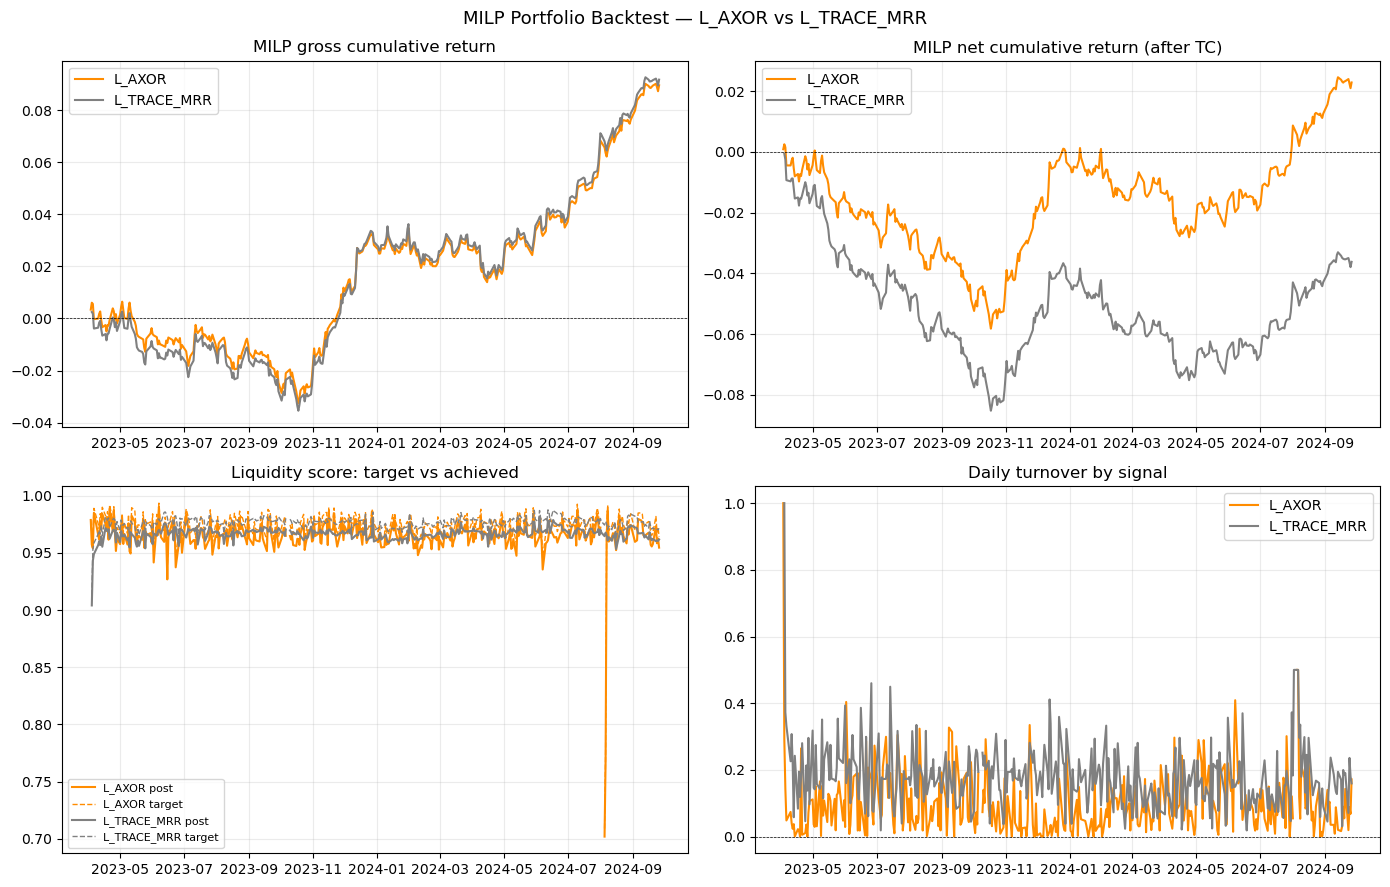


=== MILP BACKTEST SUMMARY ===

L_AXOR:
  Days solved:      373
  Gross Sharpe:     1.5415
  Net Sharpe:       0.4198
  Cum gross return: 0.0896
  Cum net return:   0.0228
  Mean turnover:    0.0964
  Mean TC/day:      0.000170
  Mean liq score:   0.9648

L_TRACE_MRR:
  Days solved:      373
  Gross Sharpe:     1.5789
  Net Sharpe:       -0.6385
  Cum gross return: 0.0918
  Cum net return:   -0.0362
  Mean turnover:    0.1765
  Mean TC/day:      0.000336
  Mean liq score:   0.9667


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

colors = {"L_AXOR": "darkorange", "L_TRACE_MRR": "gray"}

# cumulative gross return
ax = axes[0, 0]
for sig, res in milp_results.items():
    cum = (1 + res["gross"]).cumprod() - 1
    cum.index = pd.to_datetime(cum.index)
    ax.plot(cum.index, cum.values, label=sig, color=colors[sig])
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_title("MILP gross cumulative return")
ax.legend()
ax.grid(alpha=0.25)

# cumulative net return
ax = axes[0, 1]
for sig, res in milp_results.items():
    cum = (1 + res["net"]).cumprod() - 1
    cum.index = pd.to_datetime(cum.index)
    ax.plot(cum.index, cum.values, label=sig, color=colors[sig])
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_title("MILP net cumulative return (after TC)")
ax.legend()
ax.grid(alpha=0.25)

# liquidity score over time
ax = axes[1, 0]
for sig, res in milp_results.items():
    df = res["daily"]
    df["date"] = pd.to_datetime(df["date"])
    ax.plot(df["date"], df["post_liq_score"],
            label=f"{sig} post", color=colors[sig], linewidth=1.5)
    ax.plot(df["date"], df["objective_liq_score"],
            label=f"{sig} target", color=colors[sig], linewidth=1, linestyle="--")
ax.set_title("Liquidity score: target vs achieved")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# turnover over time
ax = axes[1, 1]
for sig, res in milp_results.items():
    df = res["daily"]
    df["date"] = pd.to_datetime(df["date"])
    ax.plot(df["date"], df["turnover"],
            label=sig, color=colors[sig], linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_title("Daily turnover by signal")
ax.legend()
ax.grid(alpha=0.25)

plt.suptitle("MILP Portfolio Backtest — L_AXOR vs L_TRACE_MRR", fontsize=13)
plt.tight_layout()
plt.show()

# summary table
print("\n=== MILP BACKTEST SUMMARY ===")
for sig, res in milp_results.items():
    df = res["daily"]
    gross_s = res["gross"]
    net_s = res["net"]
    print(f"\n{sig}:")
    print(f"  Days solved:      {len(df)}")
    print(f"  Gross Sharpe:     {np.sqrt(252) * gross_s.mean() / gross_s.std():.4f}")
    print(f"  Net Sharpe:       {np.sqrt(252) * net_s.mean() / net_s.std():.4f}")
    print(f"  Cum gross return: {(1+gross_s).prod()-1:.4f}")
    print(f"  Cum net return:   {(1+net_s).prod()-1:.4f}")
    print(f"  Mean turnover:    {df['turnover'].mean():.4f}")
    print(f"  Mean TC/day:      {df['predicted_tc'].mean():.6f}")
    print(f"  Mean liq score:   {df['post_liq_score'].mean():.4f}")


In [ ]:
milp_price_results = {}
for mark in ["P_TRACE", "P_AXOR", "P_BCQ"]:
    daily_df, gross_s, net_s = run_milp_backtest(panel, "L_AXOR", mark_col=mark)
    milp_price_results[mark] = {"daily": daily_df, "gross": gross_s, "net": net_s}
from bond_portfolio_milp import summarize_backtest
for mark, res in milp_price_results.items():
    print(mark, summarize_backtest(res["daily"], res["gross"], res["net"]))

P_TRACE {'days_solved': 371, 'gross_sharpe': 1.5414580295261322, 'net_sharpe': 0.41975629235507544, 'cum_gross_return': 0.08957919704010497, 'cum_net_return': 0.022825390320407424, 'mean_turnover': 0.09641378464990065, 'mean_predicted_tc': 0.00017043961116356695, 'mean_realized_tc': 0.00020275589553181143, 'total_predicted_tc': 0.06323309574168334, 'total_realized_tc': 0.07522243724230204, 'mean_liq_score': 0.964772482547354, 'mean_duration': 4.0008230394892434, 'mean_hy_weight': 1.0}
P_AXOR {'days_solved': 371, 'gross_sharpe': 1.5414580295261322, 'net_sharpe': 0.41975629235507544, 'cum_gross_return': 0.08957919704010497, 'cum_net_return': 0.022825390320407424, 'mean_turnover': 0.09641378464990065, 'mean_predicted_tc': 0.00017043961116356695, 'mean_realized_tc': 0.00020275589553181143, 'total_predicted_tc': 0.06323309574168334, 'total_realized_tc': 0.07522243724230204, 'mean_liq_score': 0.964772482547354, 'mean_duration': 4.0008230394892434, 'mean_hy_weight': 1.0}
P_BCQ {'days_solved':

## 12. Liquidity-Adjusted MILP

In [ ]:
from bond_portfolio_milp import POLICY, apply_eligibility, solve_stage_a, solve_stage_b
from bond_portfolio_milp import RETURN_COL  # FIX 8: score on total return
from scipy.optimize import milp, LinearConstraint, Bounds
import numpy as np
import warnings

CAP_BUFFER = 0.05   # headroom so sum(w)=1 stays reachable after per-bond/issuer caps
BAD_FITNESS = -1e6  # sentinel must be worse than any achievable Sharpe, else the GA
                    # maximizes its way into the rejected region


def _feasible_group_caps(groups, w_max_i, cap, buffer=CAP_BUFFER):
    """Per-group caps that cannot make a fully invested book impossible.

    Capping a group at `cap` forces the *other* groups to supply 1 - cap. When the
    complement's per-bond caps cannot cover that residual the LP is infeasible --
    e.g. a 2-sector day where 'Domestic bonds' holds 4 names but the 0.90 sector cap
    on 'International bonds' requires those 4 names to absorb 10% of the book.
    """
    caps, total = {}, float(w_max_i.sum())
    n_groups = max(len(groups), 1)
    floor_cap = (1.0 + buffer) / n_groups if n_groups * cap < 1.0 + buffer else cap
    for key, idx in groups.items():
        outside = total - float(w_max_i[list(idx)].sum())
        needed = (1.0 - outside) * (1.0 + buffer)
        caps[key] = float(min(1.0, max(cap, floor_cap, needed)))
    return caps


def solve_stage_a_liq_adjusted(df, liq_col, policy=None, base_cap=0.01, scale=2.0):
    if policy is None:
        policy = POLICY.copy()
    df = df.reset_index(drop=True)
    n = len(df)

    raw = np.nan_to_num(df[liq_col].to_numpy(float), nan=0.0)
    r_min, r_max = raw.min(), raw.max()
    if r_max > r_min:
        raw_norm = (raw - r_min) / (r_max - r_min)
    else:
        raw_norm = np.ones(n)
    alpha = 1 - raw_norm

    w_max_i = base_cap * (1 + scale * alpha)
    w_max_i = np.clip(w_max_i, base_cap * 0.5, base_cap * (1 + scale))

    # A small cardinality with tight per-bond caps makes sum(w)=1 unreachable
    # (e.g. K=56 -> sum(w_max_i)=0.97). Rescale proportionally, which preserves
    # the liquidity ordering of the caps.
    total_cap = float(w_max_i.sum())
    caps_rescaled = total_cap < 1.0 + CAP_BUFFER
    if caps_rescaled and total_cap > 0:
        w_max_i = np.minimum(w_max_i * (1.0 + CAP_BUFFER) / total_cap, 1.0)

    c = -alpha
    lb = np.zeros(n)
    ub = w_max_i

    rows, b_lo, b_hi = [], [], []
    rows.append(np.ones(n))
    b_lo.append(1.0)
    b_hi.append(1.0)

    issuers = df["issuer_name"].fillna("UNKNOWN").astype(str)
    issuer_groups = df.groupby(issuers).groups
    issuer_caps = _feasible_group_caps(issuer_groups, w_max_i,
                                       float(policy["max_weight_single_issuer"]))
    for key, idx in issuer_groups.items():
        row = np.zeros(n)
        row[list(idx)] = 1.0
        rows.append(row)
        b_lo.append(-np.inf)
        b_hi.append(issuer_caps[key])

    sectors = df["sector"].fillna("UNKNOWN").astype(str)
    if sectors.nunique() > 1:
        sector_groups = df.groupby(sectors).groups
        sector_caps = _feasible_group_caps(sector_groups, w_max_i,
                                           float(policy["max_weight_single_sector"]))
        for key, idx in sector_groups.items():
            row = np.zeros(n)
            row[list(idx)] = 1.0
            rows.append(row)
            b_lo.append(-np.inf)
            b_hi.append(sector_caps[key])

    constraints = [LinearConstraint(np.vstack(rows), np.array(b_lo), np.array(b_hi))]
    result = milp(c, bounds=Bounds(lb, ub), constraints=constraints)
    if not result.success:
        raise RuntimeError(f"Stage A (liq-adjusted) failed: {result.message}")

    w = np.clip(result.x, 0.0, w_max_i)
    w = w / w.sum()

    meta = {
        "objective_liq_score": float(w @ alpha),
        "n_held":              int((w > 1e-8).sum()),
        "max_weight":          float(w.max()),
        "min_weight":          float(w[w > 1e-8].min()),
        "liq_col":             liq_col,
        "w_max_i":             w_max_i,
        "caps_rescaled":       bool(caps_rescaled),
        "max_issuer_cap_used": float(max(issuer_caps.values())) if issuer_caps else np.nan,
    }
    return w, meta


def solve_stage_b_liq_adjusted(df, w0, target_liq_score, liq_col, w_max_i,
                               policy=None, enforce_turnover=True):
    """Stage B using per-bond caps from liquidity-adjusted Stage A."""
    if policy is None:
        policy = POLICY
    df = df.reset_index(drop=True)
    n = len(df)

    raw = np.nan_to_num(df[liq_col].to_numpy(float), nan=0.0)
    r_min, r_max = raw.min(), raw.max()
    if r_max > r_min:
        raw_norm = (raw - r_min) / (r_max - r_min)
    else:
        raw_norm = np.ones(n)
    alpha = 1 - raw_norm

    if "L_BCQ_pct" in df.columns:
        tc_est = df["L_BCQ_pct"].fillna(df["L_AXOR_pct"]).to_numpy(float)
    else:
        tc_est = df["L_AXOR_pct"].to_numpy(float)
    tc_est = np.nan_to_num(tc_est, nan=float(np.nanmedian(df["L_AXOR_pct"])))
    # A zero-cost bond makes buying and selling the same name free, so the solver
    # can inflate matching b_i / s_i pairs and report absurd turnover. A strictly
    # positive cost keeps the round trip penalized.
    tc_est = np.maximum(tc_est, 1e-6)

    nvar = 3 * n
    idx_w = slice(0, n)
    idx_b = slice(n, 2 * n)
    idx_s = slice(2 * n, 3 * n)

    c = np.zeros(nvar)
    c[idx_b] = tc_est / 2
    c[idx_s] = tc_est / 2

    lb = np.zeros(nvar)
    ub = np.concatenate([w_max_i, np.ones(n), np.ones(n)])

    rows, b_lo, b_hi = [], [], []

    # flow conservation: w_i = w0_i + b_i - s_i
    for i in range(n):
        row = np.zeros(nvar)
        row[i] = 1.0
        row[n + i] = -1.0
        row[2 * n + i] = 1.0
        rows.append(row)
        b_lo.append(w0[i])
        b_hi.append(w0[i])

    row = np.zeros(nvar)
    row[idx_w] = 1.0
    rows.append(row)
    b_lo.append(1.0)
    b_hi.append(1.0)

    issuers = df["issuer_name"].fillna("UNKNOWN").astype(str)
    issuer_groups = df.groupby(issuers).groups
    issuer_caps = _feasible_group_caps(issuer_groups, w_max_i,
                                       float(policy["max_weight_single_issuer"]))
    for key, idx in issuer_groups.items():
        row = np.zeros(nvar)
        row[list(idx)] = 1.0
        rows.append(row)
        b_lo.append(-np.inf)
        b_hi.append(issuer_caps[key])

    sectors = df["sector"].fillna("UNKNOWN").astype(str)
    if sectors.nunique() > 1:
        sector_groups = df.groupby(sectors).groups
        sector_caps = _feasible_group_caps(sector_groups, w_max_i,
                                           float(policy["max_weight_single_sector"]))
        for key, idx in sector_groups.items():
            row = np.zeros(nvar)
            row[list(idx)] = 1.0
            rows.append(row)
            b_lo.append(-np.inf)
            b_hi.append(sector_caps[key])

    # The liquidity floor and the turnover cap can conflict on thin days. Relax the
    # floor first -- it is an internal target -- and only drop the turnover cap as a
    # last resort, since turnover is real money. Turnover is uncapped on day 1,
    # where building the book from cash necessarily costs sum(w) = 1.
    is_initial = bool(np.isclose(np.sum(w0), 0.0))
    can_cap = enforce_turnover and (not is_initial) and ("max_turnover" in policy)
    attempts = [(fs, 1.0) for fs in (0.99, 0.95, 0.90, 0.80)] if can_cap else []
    attempts += [(0.80, 4.0), (0.99, None)] if can_cap else [(0.99, None)]

    base_rows, base_lo, base_hi = rows, b_lo, b_hi
    result = None
    for floor_scale, cap_mult in attempts:
        use_cap = cap_mult is not None
        rows = list(base_rows)
        b_lo = list(base_lo)
        b_hi = list(base_hi)

        row = np.zeros(nvar)
        row[idx_w] = -alpha
        rows.append(row)
        b_lo.append(-np.inf)
        b_hi.append(-target_liq_score * floor_scale)

        if use_cap:
            row = np.zeros(nvar)
            row[idx_b] = 1.0
            row[idx_s] = 1.0
            rows.append(row)
            b_lo.append(-np.inf)
            b_hi.append(float(policy["max_turnover"]) * cap_mult)

        constraints = [LinearConstraint(np.vstack(rows), np.array(b_lo), np.array(b_hi))]
        result = milp(c, bounds=Bounds(lb, ub), constraints=constraints)
        if result.success:
            cap_applied, floor_used = use_cap, floor_scale
            break
    if result is None or not result.success:
        raise RuntimeError(f"Stage B failed: {result.message if result else 'no attempt'}")

    w = np.clip(result.x[idx_w], 0.0, w_max_i)
    w = w / w.sum()
    b = result.x[idx_b]
    s = result.x[idx_s]
    tc_total = float(np.maximum(0, (tc_est / 2) * b).sum() + np.maximum(0, (tc_est / 2) * s).sum())

    meta = {
        "post_liq_score":      float(w @ alpha),
        "turnover":            float(b.sum() + s.sum()),
        "turnover_cap_active": bool(cap_applied),
        "liq_floor_scale":     float(floor_used),
        "predicted_tc":        tc_total,
        "n_held_after":        int((w > 1e-8).sum()),
        "liq_col":             liq_col,
    }
    return w, meta


# ---------------------------------------------------------------------------
# Constraint tuner: Genetic Algorithm (+ Particle Swarm cross-check)
# Cardinality and the per-bond weight cap are treated as hyperparameters and
# scored by net Sharpe on a rolling lookback under market friction
# (turnover x half-spread), with the same turnover cap the optimizer faces.
# ---------------------------------------------------------------------------
try:
    import pygad
except ImportError as e:
    raise ImportError(
        "pygad is missing in THIS notebook kernel. Run  %pip install pygad pyswarms  "
        "in a cell, then Restart Kernel."
    ) from e

try:
    import pyswarms as ps
except ImportError as e:
    raise ImportError(
        "pyswarms is missing in THIS notebook kernel. Run  %pip install pyswarms  "
        "then Restart Kernel."
    ) from e


def build_eligible_panel(panel):
    """Apply the eligibility screen once, per date, so the tuner and the optimizer
    search the same universe. Doing it inside the fitness loop was the main reason
    a single tuning pass took hours."""
    out = panel
    out = out[out["P_TRACE"].notna() & out["issuer_name"].notna()]
    out = out[out["outstanding_amount"] >= 100_000_000]
    out = out[out["years_to_maturity"].between(1.0, 15.0)]
    return out.drop_duplicates(subset=["date", "cusip"]).reset_index(drop=True)


def _spread_series(df):
    if "L_BCQ_pct" in df.columns and "L_AXOR_pct" in df.columns:
        return df["L_BCQ_pct"].fillna(df["L_AXOR_pct"])
    if "L_AXOR_pct" in df.columns:
        return df["L_AXOR_pct"]
    return pd.Series(0.001, index=df.index)


def prepare_lookback(lookback, liq_col):
    """Flatten the lookback window into per-date numpy arrays once, so each GA/PSO
    fitness call is array math instead of repeated DataFrame filtering."""
    df = lookback.dropna(subset=[liq_col, RETURN_COL]).copy()
    if df.empty:
        return [], 0
    df["_spread"] = np.nan_to_num(_spread_series(df).to_numpy(float), nan=0.001)
    codes, uniques = pd.factorize(df["cusip"])
    df["_code"] = codes
    prepped = []
    for _, g in df.groupby("date", sort=True):
        prepped.append((
            g["_code"].to_numpy(),
            g[liq_col].to_numpy(float),
            g[RETURN_COL].to_numpy(float),
            g["_spread"].to_numpy(float),
        ))
    return prepped, len(uniques)


def _capped_weights(liq_vals, w_cap):
    """Liquidity-tilted weights subject to a per-bond cap (proxy for Stage A)."""
    span = liq_vals.max() - liq_vals.min()
    a = np.ones_like(liq_vals) if span <= 0 else 1.0 - (liq_vals - liq_vals.min()) / span
    if a.sum() <= 0:
        a = np.ones_like(liq_vals)
    w = a / a.sum()
    for _ in range(3):
        w = np.minimum(w, w_cap)
        total = w.sum()
        if total <= 0:
            return np.full_like(liq_vals, 1.0 / len(liq_vals))
        w = w / total
    return w


def evaluate_constraint_set(prepped, n_codes, cardinality, weight_cap,
                            max_turnover=0.5, ann_factor=252):
    """Net Sharpe of a trial constraint set over the lookback window."""
    K = int(cardinality)
    w_cap = float(weight_cap)
    if K < 10 or w_cap <= 0 or n_codes == 0:
        return BAD_FITNESS
    if K * w_cap < 1.0:
        return BAD_FITNESS   # cannot be fully invested; infeasible by construction

    w_prev = np.zeros(n_codes)
    invested = False
    rets = []

    for codes, liq, ret, spr in prepped:
        if len(codes) < K:
            continue
        sel = np.argpartition(liq, K - 1)[:K]
        w_t = np.zeros(n_codes)
        w_t[codes[sel]] = _capped_weights(liq[sel], w_cap)

        delta = w_t - w_prev
        raw_turnover = float(np.abs(delta).sum())
        if invested and raw_turnover > max_turnover > 0:
            w_new = w_prev + (max_turnover / raw_turnover) * delta
            turnover = max_turnover
        else:
            w_new = w_t
            turnover = raw_turnover

        half_spread = float(np.median(spr[sel])) / 2.0
        gross = float(w_new[codes] @ ret)
        rets.append(gross - turnover * half_spread)
        w_prev = w_new
        invested = True

    if len(rets) < 5:
        return BAD_FITNESS
    r = pd.Series(rets)
    sd = r.std()
    if sd <= 0 or not np.isfinite(sd):
        return BAD_FITNESS
    return float(np.sqrt(ann_factor) * r.mean() / sd)


def _search_box(regime):
    """(cardinality range, concentration-multiplier range).

    weight_cap = multiplier / cardinality, so K * w_cap >= 1 always holds and the
    search space contains no infeasible corner for the GA to exploit.
    High liquidity  -> tighter book, more concentration.
    Low liquidity   -> wider book, flatter weights, less trapped in illiquid names.
    """
    if regime == "high_liquidity":
        return (40, 90), (1.5, 3.0)
    if regime == "low_liquidity":
        return (90, 180), (1.0, 1.8)
    return (60, 140), (1.2, 2.5)


def _decode(genes, regime):
    (k_lo, k_hi), (m_lo, m_hi) = _search_box(regime)
    K = int(np.clip(round(float(genes[0])), k_lo, k_hi))
    m = float(np.clip(float(genes[1]), m_lo, m_hi))
    w_cap = float(np.clip(m / K, 0.005, 0.05))
    if K * w_cap < 1.0:
        w_cap = min(0.05, 1.0 / K * 1.05)
    return K, w_cap


def liquidity_regime(day, lookback, spread_col="L_AXOR_pct"):
    """Wide prevailing spreads = stress; tight spreads = high liquidity."""
    if spread_col not in lookback.columns or lookback.empty:
        return "normal", float("nan")
    med = float(lookback[spread_col].median())
    ref = float(day[spread_col].median()) if spread_col in day.columns and day[spread_col].notna().any() else med
    if not np.isfinite(med) or not np.isfinite(ref) or ref <= 0:
        return "normal", med
    if med <= ref * 0.85:
        return "high_liquidity", med
    if med >= ref * 1.15:
        return "low_liquidity", med
    return "normal", med


def tune_constraints_ga_pso(lookback, liq_col, regime="normal", max_turnover=0.5,
                            sol_per_pop=16, num_generations=6, use_pso=True):
    """Population of constraint sets -> score under friction -> select and mutate."""
    prepped, n_codes = prepare_lookback(lookback, liq_col)
    if not prepped:
        return None

    (k_lo, k_hi), (m_lo, m_hi) = _search_box(regime)
    gene_space = [{"low": k_lo, "high": k_hi, "step": 1},
                  {"low": m_lo, "high": m_hi, "step": 0.05}]

    def fitness_func(ga_inst, solution, sol_idx):
        K, w_cap = _decode(solution, regime)
        return evaluate_constraint_set(prepped, n_codes, K, w_cap, max_turnover)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ga = pygad.GA(
            num_generations=num_generations,
            num_parents_mating=max(2, sol_per_pop // 4),
            fitness_func=fitness_func,
            sol_per_pop=sol_per_pop,
            num_genes=2,
            gene_space=gene_space,
            parent_selection_type="tournament",
            keep_elitism=2,
            crossover_type="single_point",
            mutation_type="random",
            mutation_percent_genes=30,
            suppress_warnings=True,
        )
        ga.run()
    best_genes, best_fit, _ = ga.best_solution()
    K, w_cap = _decode(best_genes, regime)
    meta = {"engine": "GA", "fitness": float(best_fit), "regime": regime}

    if use_pso:
        lo = np.array([k_lo, m_lo], dtype=float)
        hi = np.array([k_hi, m_hi], dtype=float)

        def pso_cost(X):
            costs = np.empty(X.shape[0])
            for i in range(X.shape[0]):
                Ki, wi = _decode(X[i], regime)
                costs[i] = -evaluate_constraint_set(prepped, n_codes, Ki, wi, max_turnover)
            return costs

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            swarm = ps.single.GlobalBestPSO(
                n_particles=min(12, sol_per_pop),
                dimensions=2,
                options={"c1": 0.5, "c2": 0.3, "w": 0.9},
                bounds=(lo, hi),
            )
            best_cost, best_pos = swarm.optimize(pso_cost, iters=max(4, num_generations // 2),
                                                 verbose=False)
        if -float(best_cost) > best_fit:
            K, w_cap = _decode(best_pos, regime)
            meta = {"engine": "PSO", "fitness": -float(best_cost), "regime": regime}

    return K, w_cap, meta


def run_milp_backtest_liq_adjusted(panel, liq_col, policy=None, lookback_days=40,
                                   retune_every=10, sol_per_pop=16, num_generations=6,
                                   use_pso=True, verbose_every=40):
    base_policy = POLICY.copy() if policy is None else dict(policy)
    max_turnover = float(base_policy.get("max_turnover", 0.5))

    elig_panel = build_eligible_panel(panel)
    dates = sorted(elig_panel["date"].unique())
    by_date = {d: g for d, g in elig_panel.groupby("date", sort=True)}

    daily_rows, gross_returns, net_returns = [], [], []
    port_w = port_cusips = prev_nav = None

    dyn_card = 100
    dyn_wcap = float(base_policy.get("max_weight_single_bond", 0.01))
    last_regime = None
    days_since_tune = 10 ** 6

    for i, date in enumerate(dates):
        sub_full = by_date[date].dropna(subset=[liq_col]).reset_index(drop=True)
        if len(sub_full) < 50:
            continue

        lo = max(0, i - lookback_days)
        window = dates[lo:i]
        lookback = elig_panel[elig_panel["date"].isin(set(window))] if window else elig_panel.iloc[0:0]

        regime, med_spread = liquidity_regime(sub_full, lookback)
        days_since_tune += 1
        can_tune = lookback["date"].nunique() >= 8 if len(lookback) else False
        need_tune = can_tune and (days_since_tune >= retune_every or regime != last_regime)

        try:
            if need_tune:
                tuned = tune_constraints_ga_pso(
                    lookback, liq_col, regime=regime, max_turnover=max_turnover,
                    sol_per_pop=sol_per_pop, num_generations=num_generations, use_pso=use_pso,
                )
                if tuned is not None:
                    dyn_card, dyn_wcap, tune_meta = tuned
                    days_since_tune = 0
                    last_regime = regime
                    print(f"  {pd.Timestamp(date).date()}: tune[{tune_meta['engine']}] "
                          f"regime={regime} card={dyn_card} w_cap={dyn_wcap:.4f} "
                          f"fit={tune_meta['fitness']:.3f}")

            day_policy = dict(base_policy)
            day_policy["max_weight_single_bond"] = dyn_wcap

            K = min(dyn_card, len(sub_full))
            target = sub_full.nsmallest(K, liq_col)
            # Bonds already held must stay in the optimization even after they drop
            # out of the top-K, otherwise the trades needed to exit them are invisible
            # to the turnover cap and the book silently re-sorts every day.
            if port_cusips:
                still_held = sub_full[sub_full["cusip"].isin(port_cusips)]
                sub = (pd.concat([target, still_held])
                       .drop_duplicates(subset=["cusip"])
                       .reset_index(drop=True))
            else:
                sub = target.reset_index(drop=True)

            w_target, meta_a = solve_stage_a_liq_adjusted(sub, liq_col, policy=day_policy)
            w_max_i = meta_a["w_max_i"]

            if port_w is None:
                w0 = np.zeros(len(sub))
            else:
                prev_series = pd.Series(port_w, index=port_cusips)
                w0 = sub["cusip"].map(prev_series).fillna(0.0).to_numpy(float)
                if w0.sum() > 0:
                    w0 = w0 / w0.sum()

            w_final, meta_b = solve_stage_b_liq_adjusted(
                sub, w0, meta_a["objective_liq_score"], liq_col, w_max_i, policy=day_policy
            )

            # Gross return from the bonds actually held. The old NAV route
            # (w @ P_TRACE) mixes price level with composition, so a change in
            # cardinality alone moved "return" even when nothing was earned.
            if RETURN_COL in sub.columns:
                rets = np.nan_to_num(sub[RETURN_COL].to_numpy(float), nan=0.0)
                gross_ret = float(w_final @ rets)
            else:
                gross_ret = 0.0

            marks = sub["P_TRACE"].to_numpy(float)
            nav = float(np.sum(w_final * marks))
            nav_ret = (nav - prev_nav) / prev_nav if (prev_nav is not None and prev_nav > 0) else 0.0

            tc = abs(meta_b["predicted_tc"])
            net_ret = gross_ret - tc

            gross_returns.append({"date": date, "return": gross_ret})
            net_returns.append({"date": date, "return": net_ret})
            daily_rows.append({
                "date":                date,
                "liq_col":             liq_col,
                "n_eligible":          len(sub),
                "n_held":              meta_b["n_held_after"],
                "cardinality_cap":     K,
                "weight_cap":          dyn_wcap,
                "regime":              regime,
                "median_spread":       med_spread,
                "caps_rescaled":       meta_a["caps_rescaled"],
                "objective_liq_score": meta_a["objective_liq_score"],
                "post_liq_score":      meta_b["post_liq_score"],
                "turnover":            meta_b["turnover"],
                "turnover_cap_active": meta_b["turnover_cap_active"],
                "liq_floor_scale":     meta_b["liq_floor_scale"],
                "predicted_tc":        tc,
                "nav":                 nav,
                "nav_return":          nav_ret,
                "gross_return":        gross_ret,
                "net_return":          net_ret,
            })

            port_w = w_final
            port_cusips = sub["cusip"].tolist()
            prev_nav = nav

            if verbose_every and (i + 1) % verbose_every == 0:
                print(f"  {pd.Timestamp(date).date()}: done ({i+1}/{len(dates)})")

        except Exception as e:
            daily_rows.append({"date": date, "liq_col": liq_col, "error": str(e)})
            continue

    daily_df = pd.DataFrame(daily_rows)
    gross_s = pd.Series({r["date"]: r["return"] for r in gross_returns})
    net_s = pd.Series({r["date"]: r["return"] for r in net_returns})
    return daily_df, gross_s, net_s


# run
milp_liq_results = {}
for sig in ["L_AXOR", "L_TRACE_MRR"]:
    print(f"\nRunning liquidity-adjusted MILP + GA/PSO constraint tuner: {sig}")
    daily_df, gross_s, net_s = run_milp_backtest_liq_adjusted(panel, sig)
    milp_liq_results[sig] = {"daily": daily_df, "gross": gross_s, "net": net_s}

    n_err = int(daily_df["error"].notna().sum()) if "error" in daily_df.columns else 0
    print(f"  rows={len(daily_df)}  solved={len(gross_s)}  errors={n_err}")
    if n_err:
        print(daily_df["error"].value_counts().head(3).to_string())
    gs = np.sqrt(252) * gross_s.mean() / gross_s.std() if len(gross_s) and gross_s.std() > 0 else np.nan
    ns = np.sqrt(252) * net_s.mean() / net_s.std() if len(net_s) and net_s.std() > 0 else np.nan
    print(f"  gross Sharpe: {gs:.4f}")
    print(f"  net Sharpe:   {ns:.4f}")
    if len(daily_df) and "regime" in daily_df.columns:
        ok = daily_df[daily_df.get("regime").notna()] if "regime" in daily_df.columns else daily_df
        print("  regime mix:\n" + ok["regime"].value_counts().to_string())
        print("  mean cardinality / weight cap / turnover by regime:")
        print(ok.groupby("regime")[["cardinality_cap", "weight_cap", "turnover"]].mean().to_string())



Running liquidity-adjusted MILP + GA/PSO constraint tuner: L_AXOR
  2023-04-14: tune[PSO] regime=normal card=74 w_cap=0.0164 fit=-8.992
  2023-04-28: tune[GA] regime=normal card=139 w_cap=0.0090 fit=-7.800
  2023-05-12: tune[GA] regime=normal card=126 w_cap=0.0095 fit=-7.299
  2023-05-26: tune[PSO] regime=normal card=139 w_cap=0.0087 fit=-10.363
  2023-05-30: done (40/373)
  2023-06-12: tune[GA] regime=normal card=133 w_cap=0.0098 fit=-9.881
  2023-06-27: tune[GA] regime=normal card=135 w_cap=0.0093 fit=-11.589
  2023-07-03: tune[PSO] regime=low_liquidity card=91 w_cap=0.0112 fit=-13.512
  2023-07-18: tune[GA] regime=low_liquidity card=179 w_cap=0.0056 fit=-8.707
  2023-07-28: done (80/373)
  2023-08-01: tune[PSO] regime=low_liquidity card=175 w_cap=0.0057 fit=-9.328
  2023-08-14: tune[GA] regime=normal card=119 w_cap=0.0101 fit=-7.930
  2023-08-16: tune[GA] regime=low_liquidity card=117 w_cap=0.0085 fit=-8.104
  2023-08-17: tune[GA] regime=normal card=115 w_cap=0.0104 fit=-8.621
  20

=== MILP COMPARISON: FIXED vs LIQUIDITY-ADJUSTED ===

                                      Fixed      Liq-Adj
                               L_AXOR    MRR L_AXOR    MRR
------------------------------------------------------------
Days solved                    373 373 373 373
Gross Sharpe                   1.5415 1.5789 3.3313 2.3204
Net Sharpe                     0.4198 -0.6385 -1.4603 0.1545
Cum gross return               0.0896 0.0918 0.0856 0.0821
Cum net return                 0.0228 -0.0362 -0.0360 0.0049
Mean turnover                  0.0964 0.1765 0.2353 0.1282
Mean TC/day                    0.000170 0.000336 0.000318 0.000198
Mean liq score                 0.9648 0.9667 0.9015 0.9323
Mean bonds held                111.2 106.0 41.9 44.3


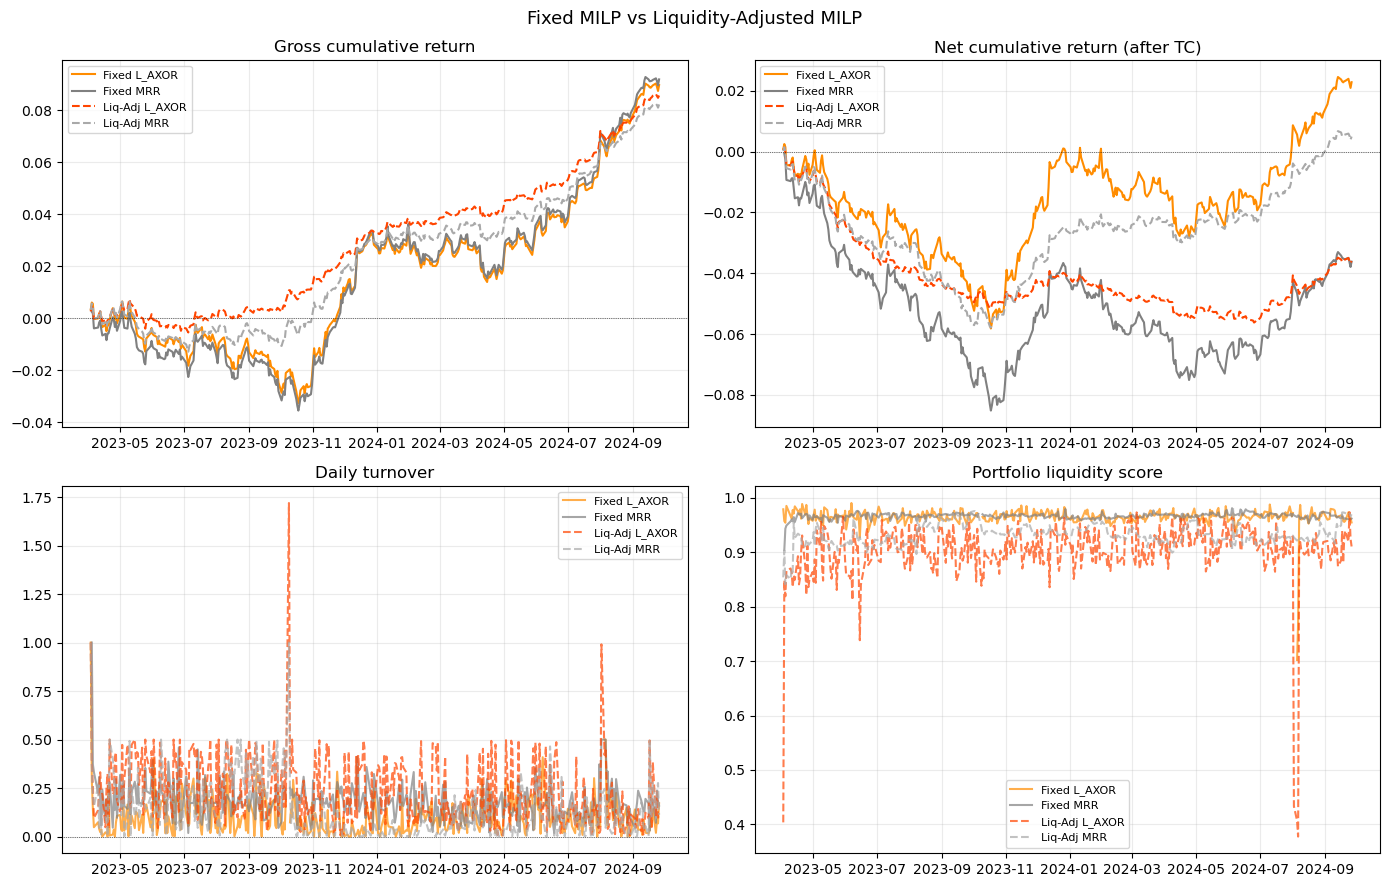

In [ ]:
# full comparison: fixed vs liquidity-adjusted, L_AXOR vs L_TRACE_MRR
# Needs milp_results (fixed MILP from Section 11) + milp_liq_results (previous cell).
if "milp_results" not in globals() or not milp_results:
    from bond_portfolio_milp import run_milp_backtest
    print("milp_results missing — running fixed MILP baseline first...")
    milp_results = {}
    for sig in ["L_AXOR", "L_TRACE_MRR"]:
        print(f"\nRunning MILP backtest: {sig}")
        daily_df, gross_s, net_s = run_milp_backtest(panel, sig)
        milp_results[sig] = {"daily": daily_df, "gross": gross_s, "net": net_s}
        print(f"  completed: {len(daily_df)} days")

if "milp_liq_results" not in globals() or not milp_liq_results:
    raise NameError(
        "milp_liq_results missing — run the previous Liquidity-Adjusted MILP cell first"
    )

print("=== MILP COMPARISON: FIXED vs LIQUIDITY-ADJUSTED ===\n")
print(f"{'':30} {'Fixed':>12} {'Liq-Adj':>12}")
print(f"{'':30} {'L_AXOR':>6} {'MRR':>6} {'L_AXOR':>6} {'MRR':>6}")
print("-" * 60)

metrics = [
    ("Days solved",      "n",  lambda r: len(r["daily"])),
    ("Gross Sharpe",     ".4f", lambda r: np.sqrt(252)*r["gross"].mean()/r["gross"].std()),
    ("Net Sharpe",       ".4f", lambda r: np.sqrt(252)*r["net"].mean()/r["net"].std()),
    ("Cum gross return", ".4f", lambda r: (1+r["gross"]).prod()-1),
    ("Cum net return",   ".4f", lambda r: (1+r["net"]).prod()-1),
    ("Mean turnover",    ".4f", lambda r: r["daily"]["turnover"].mean()),
    ("Mean TC/day",      ".6f", lambda r: r["daily"]["predicted_tc"].mean()),
    ("Mean liq score",   ".4f", lambda r: r["daily"]["post_liq_score"].mean()),
    ("Mean bonds held",  ".1f", lambda r: r["daily"]["n_held"].mean()),
]

for name, fmt, fn in metrics:
    fa = fn(milp_results["L_AXOR"])
    fm = fn(milp_results["L_TRACE_MRR"])
    la = fn(milp_liq_results["L_AXOR"])
    lm = fn(milp_liq_results["L_TRACE_MRR"])
    print(f"{name:30} {fa:{fmt}} {fm:{fmt}} {la:{fmt}} {lm:{fmt}}")

# plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

colors = {
    "Fixed L_AXOR":    "darkorange",
    "Fixed MRR":       "gray",
    "Liq-Adj L_AXOR":  "orangered",
    "Liq-Adj MRR":     "darkgray",
}

# gross cumulative return
ax = axes[0, 0]
for label, results in [
    ("Fixed L_AXOR",   milp_results["L_AXOR"]),
    ("Fixed MRR",      milp_results["L_TRACE_MRR"]),
    ("Liq-Adj L_AXOR", milp_liq_results["L_AXOR"]),
    ("Liq-Adj MRR",    milp_liq_results["L_TRACE_MRR"]),
]:
    cum = (1 + results["gross"]).cumprod() - 1
    cum.index = pd.to_datetime(cum.index)
    ax.plot(cum.index, cum.values, label=label, color=colors[label],
            linestyle="--" if "Liq" in label else "-")
ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax.set_title("Gross cumulative return")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# net cumulative return
ax = axes[0, 1]
for label, results in [
    ("Fixed L_AXOR",   milp_results["L_AXOR"]),
    ("Fixed MRR",      milp_results["L_TRACE_MRR"]),
    ("Liq-Adj L_AXOR", milp_liq_results["L_AXOR"]),
    ("Liq-Adj MRR",    milp_liq_results["L_TRACE_MRR"]),
]:
    cum = (1 + results["net"]).cumprod() - 1
    cum.index = pd.to_datetime(cum.index)
    ax.plot(cum.index, cum.values, label=label, color=colors[label],
            linestyle="--" if "Liq" in label else "-")
ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax.set_title("Net cumulative return (after TC)")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# turnover comparison
ax = axes[1, 0]
for label, results in [
    ("Fixed L_AXOR",   milp_results["L_AXOR"]),
    ("Fixed MRR",      milp_results["L_TRACE_MRR"]),
    ("Liq-Adj L_AXOR", milp_liq_results["L_AXOR"]),
    ("Liq-Adj MRR",    milp_liq_results["L_TRACE_MRR"]),
]:
    df = results["daily"].copy()
    df["date"] = pd.to_datetime(df["date"])
    ax.plot(df["date"], df["turnover"], label=label, color=colors[label],
            linestyle="--" if "Liq" in label else "-", alpha=0.7)
ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax.set_title("Daily turnover")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# liquidity score comparison
ax = axes[1, 1]
for label, results in [
    ("Fixed L_AXOR",   milp_results["L_AXOR"]),
    ("Fixed MRR",      milp_results["L_TRACE_MRR"]),
    ("Liq-Adj L_AXOR", milp_liq_results["L_AXOR"]),
    ("Liq-Adj MRR",    milp_liq_results["L_TRACE_MRR"]),
]:
    df = results["daily"].copy()
    df["date"] = pd.to_datetime(df["date"])
    ax.plot(df["date"], df["post_liq_score"], label=label, color=colors[label],
            linestyle="--" if "Liq" in label else "-", alpha=0.7)
ax.set_title("Portfolio liquidity score")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

plt.suptitle("Fixed MILP vs Liquidity-Adjusted MILP", fontsize=13)
plt.tight_layout()
plt.show()

## 12b. Layer 2 — enforcing the learned constraints with a binary roster

Section 12 completes Layer 1 of the plan: a GA/PSO tuner learns the cardinality `K`
and the per-bond weight cap from a rolling lookback. But it enforces cardinality by
truncating the universe to the `K` most liquid names before optimizing, which is a
**data filter, not a constraint** — the solver never gets to decide whether a
slightly less liquid bond is worth holding because it is far cheaper to trade.

This section adds Layer 2. The roster becomes a genuine binary decision `z_i`, with
semi-continuous weights `w_min * z_i <= w_i <= cap_i * z_i`, so a selected bond must
carry a real position rather than a rounding error. That makes the model an actual
MILP rather than the LP the earlier sections were solving.

Two engines solve the identical model:

- **Benders decomposition** (`benders_portfolio.solve_roster_benders`) — the plan's
  choice. A master picks the roster, an elastic sub-problem allocates weights, and
  the sub-problem duals on the linking constraint feed optimality cuts back to the
  master. Local branching keeps the master near its incumbent.
- **Branch-and-cut** (`benders_portfolio.solve_roster_direct_milp`) — the whole MILP
  handed to HiGHS in one piece.

The next cells run the backtest and then benchmark the two engines head to head.


In [ ]:
import importlib

import benders_portfolio as _bp
importlib.reload(_bp)
from benders_portfolio import solve_roster_benders, solve_roster_direct_milp
from bond_portfolio_milp import RETURN_COL  # FIX 8: score on total return

# Layer 2 searches a wider candidate set than the roster it will pick, so the
# binary variables have something to choose between. Anything currently held is
# unioned in: if a position is invisible to the optimizer it gets liquidated for
# free, and the turnover cap never sees the trade.
N_CANDIDATES = 250


def _layer2_candidates(day_df, liq_col, held_cusips, n_candidates=N_CANDIDATES):
    cand = day_df.nsmallest(min(n_candidates, len(day_df)), liq_col)
    if held_cusips:
        held = day_df[day_df["cusip"].isin(held_cusips)]
        cand = pd.concat([cand, held]).drop_duplicates(subset=["cusip"])
    return cand.reset_index(drop=True)


def run_backtest_layer2(panel, liq_col, policy=None, solver="milp", lookback_days=40,
                        retune_every=10, use_pso=True, n_candidates=N_CANDIDATES,
                        floor_scale=0.75, min_weight_frac=0.5,
                        cardinality_mode="cap", verbose_every=60):
    """Layer 1 (GA/PSO) sets the rules; Layer 2 enforces them with binary roster
    selection. `solver` picks which Layer 2 engine does the enforcing:
    "milp" for HiGHS branch-and-cut, "benders" for the decomposition loop."""
    base_policy = POLICY.copy() if policy is None else dict(policy)
    solve_layer2 = solve_roster_direct_milp if solver == "milp" else solve_roster_benders

    elig_panel = build_eligible_panel(panel)
    dates = sorted(elig_panel["date"].unique())
    by_date = {d: g for d, g in elig_panel.groupby("date", sort=True)}

    daily_rows, gross_returns, net_returns = [], [], []
    port_w = port_cusips = None
    dyn_card, dyn_wcap = 100, float(base_policy.get("max_weight_single_bond", 0.01))
    last_regime, days_since_tune = None, 10 ** 6

    for i, date in enumerate(dates):
        day = by_date[date].dropna(subset=[liq_col])
        if len(day) < 50:
            continue

        window = dates[max(0, i - lookback_days):i]
        lookback = elig_panel[elig_panel["date"].isin(set(window))] if window else elig_panel.iloc[0:0]
        regime, med_spread = liquidity_regime(day, lookback)

        days_since_tune += 1
        can_tune = lookback["date"].nunique() >= 8 if len(lookback) else False
        if can_tune and (days_since_tune >= retune_every or regime != last_regime):
            tuned = tune_constraints_ga_pso(
                lookback, liq_col, regime=regime,
                max_turnover=float(base_policy.get("max_turnover", 0.5)), use_pso=use_pso)
            if tuned is not None:
                dyn_card, dyn_wcap, tune_meta = tuned
                days_since_tune, last_regime = 0, regime
                print(f"  {pd.Timestamp(date).date()}: tune[{tune_meta['engine']}] "
                      f"regime={regime} K={dyn_card} w_cap={dyn_wcap:.4f} "
                      f"fit={tune_meta['fitness']:.3f}")

        try:
            sub = _layer2_candidates(day, liq_col, port_cusips, n_candidates)
            K = int(min(dyn_card, len(sub)))

            day_policy = dict(base_policy)
            day_policy["max_weight_single_bond"] = dyn_wcap

            # Stage A runs on the same candidate set Layer 2 will search, so the
            # liquidity score it targets and the one Layer 2 measures share a
            # normalization. Mismatching those makes the floor unreachable.
            _, meta_a = solve_stage_a_liq_adjusted(sub, liq_col, policy=day_policy,
                                                   base_cap=dyn_wcap, scale=2.0)

            w0 = np.zeros(len(sub))
            if port_cusips:
                prev = pd.Series(port_w, index=port_cusips)
                w0 = sub["cusip"].map(prev).fillna(0.0).to_numpy(float)
                if w0.sum() > 0:
                    w0 = w0 / w0.sum()

            w_final, meta_b = solve_layer2(
                sub, w0, meta_a["objective_liq_score"], liq_col, meta_a["w_max_i"],
                K, day_policy, floor_scale=floor_scale, min_weight_frac=min_weight_frac,
                cardinality_mode=cardinality_mode)

            rets = np.nan_to_num(sub[RETURN_COL].to_numpy(float), nan=0.0)
            gross_ret = float(w_final @ rets)
            tc = abs(meta_b["predicted_tc"])
            net_ret = gross_ret - tc

            gross_returns.append({"date": date, "return": gross_ret})
            net_returns.append({"date": date, "return": net_ret})
            daily_rows.append({
                "date": date, "liq_col": liq_col, "regime": regime,
                "n_candidates": len(sub), "cardinality_cap": K, "weight_cap": dyn_wcap,
                "n_held": meta_b["n_held_after"], "roster_size": meta_b["roster_size"],
                "median_spread": med_spread,
                "post_liq_score": meta_b["post_liq_score"],
                "turnover": meta_b["turnover"], "predicted_tc": tc,
                "gross_return": gross_ret, "net_return": net_ret,
            })

            held = w_final > 1e-8
            port_w = w_final[held]
            port_cusips = sub.loc[held, "cusip"].tolist()

            if verbose_every and (i + 1) % verbose_every == 0:
                print(f"  {pd.Timestamp(date).date()}: done ({i+1}/{len(dates)})")

        except Exception as e:
            daily_rows.append({"date": date, "liq_col": liq_col, "error": str(e)})
            continue

    daily_df = pd.DataFrame(daily_rows)
    gross_s = pd.Series({r["date"]: r["return"] for r in gross_returns})
    net_s = pd.Series({r["date"]: r["return"] for r in net_returns})
    return daily_df, gross_s, net_s


milp_layer2_results = {}
for sig in ["L_AXOR", "L_TRACE_MRR"]:
    print(f"\nLayer 1 (GA/PSO) + Layer 2 (binary roster MILP): {sig}")
    daily_df, gross_s, net_s = run_backtest_layer2(panel, sig)
    milp_layer2_results[sig] = {"daily": daily_df, "gross": gross_s, "net": net_s}

    n_err = int(daily_df["error"].notna().sum()) if "error" in daily_df.columns else 0
    print(f"  rows={len(daily_df)}  solved={len(gross_s)}  errors={n_err}")
    if n_err:
        print(daily_df["error"].value_counts().head(3).to_string())
    gs = np.sqrt(252) * gross_s.mean() / gross_s.std() if len(gross_s) and gross_s.std() > 0 else np.nan
    ns = np.sqrt(252) * net_s.mean() / net_s.std() if len(net_s) and net_s.std() > 0 else np.nan
    print(f"  gross Sharpe: {gs:.4f}   net Sharpe: {ns:.4f}")
    ok = daily_df[daily_df["turnover"].notna()] if "turnover" in daily_df.columns else daily_df
    if len(ok):
        print(f"  mean turnover {ok['turnover'].mean():.3f} | "
              f"mean bonds held {ok['n_held'].mean():.1f} (roster cap "
              f"{ok['cardinality_cap'].mean():.0f})")



Layer 1 (GA/PSO) + Layer 2 (binary roster MILP): L_AXOR
  2023-04-14: tune[GA] regime=normal K=63 w_cap=0.0190 fit=-8.893
  2023-04-28: tune[GA] regime=normal K=136 w_cap=0.0088 fit=-7.778
  2023-05-12: tune[GA] regime=normal K=133 w_cap=0.0090 fit=-7.253
  2023-05-26: tune[GA] regime=normal K=136 w_cap=0.0088 fit=-10.333
  2023-06-12: tune[GA] regime=normal K=134 w_cap=0.0093 fit=-9.859
  2023-06-27: tune[GA] regime=normal K=136 w_cap=0.0088 fit=-11.578
  2023-06-28: done (60/373)
  2023-07-03: tune[GA] regime=low_liquidity K=179 w_cap=0.0056 fit=-13.503
  2023-07-18: tune[GA] regime=low_liquidity K=160 w_cap=0.0063 fit=-8.720
  2023-08-01: tune[PSO] regime=low_liquidity K=165 w_cap=0.0062 fit=-9.332
  2023-08-14: tune[GA] regime=normal K=116 w_cap=0.0103 fit=-7.937
  2023-08-16: tune[GA] regime=low_liquidity K=118 w_cap=0.0085 fit=-8.120
  2023-08-17: tune[GA] regime=normal K=115 w_cap=0.0109 fit=-8.643
  2023-08-31: tune[GA] regime=low_liquidity K=90 w_cap=0.0111 fit=-5.099
  2023-

In [ ]:
# Does the decomposition actually pay for itself here?
# Same model, same day, two engines: the Benders master/sub loop vs handing the
# whole MILP to HiGHS branch-and-cut. "excess" is how much worse the Benders
# objective is than the branch-and-cut optimum.
import time

_bench_rows = []
_dates_bench = sorted(build_eligible_panel(panel)["date"].unique())
_elig_bench = build_eligible_panel(panel)
_port_w = _port_cusips = None

for _dt in _dates_bench[45:50]:
    _day = _elig_bench[_elig_bench["date"] == _dt].dropna(subset=["L_AXOR"])
    _cand = _day.nsmallest(250, "L_AXOR")
    if _port_cusips:
        _cand = pd.concat([_cand, _day[_day["cusip"].isin(_port_cusips)]]).drop_duplicates(subset=["cusip"])
    _sub = _cand.reset_index(drop=True)

    _K, _wcap = 100, 0.015
    _pol = dict(POLICY)
    _pol["max_weight_single_bond"] = _wcap
    _, _ma = solve_stage_a_liq_adjusted(_sub, "L_AXOR", policy=_pol, base_cap=_wcap, scale=2.0)

    _w0 = np.zeros(len(_sub))
    if _port_cusips:
        _prev = pd.Series(_port_w, index=_port_cusips)
        _w0 = _sub["cusip"].map(_prev).fillna(0.0).to_numpy(float)
        if _w0.sum() > 0:
            _w0 = _w0 / _w0.sum()

    _args = (_sub, _w0, _ma["objective_liq_score"], "L_AXOR", _ma["w_max_i"], _K, _pol)
    _kw = dict(floor_scale=0.75, min_weight_frac=0.5, cardinality_mode="cap")

    _t = time.time(); _wb, _mb = solve_roster_benders(*_args, **_kw); _tb = time.time() - _t
    _t = time.time(); _wd, _md = solve_roster_direct_milp(*_args, **_kw); _td = time.time() - _t

    _bench_rows.append({
        "date": pd.Timestamp(_dt).date(),
        "benders_obj": _mb["objective"], "branch_cut_obj": _md["objective"],
        "excess": (_mb["objective"] - _md["objective"]) / max(abs(_md["objective"]), 1e-12),
        "benders_iters": _mb["benders_iters"],
        "t_benders": _tb, "t_branch_cut": _td,
    })
    _held = _wd > 1e-8
    _port_w, _port_cusips = _wd[_held], _sub.loc[_held, "cusip"].tolist()

bench_df = pd.DataFrame(_bench_rows)
print("=== LAYER 2 ENGINE COMPARISON (identical model, identical day) ===")
print(bench_df.to_string(index=False, float_format=lambda v: f"{v:,.6f}"))
print(f"\nBenders is {bench_df['t_benders'].mean() / bench_df['t_branch_cut'].mean():.0f}x slower "
      f"and lands {bench_df['excess'].mean():.0%} above the branch-and-cut optimum on average.")
print(
    "\nWhy: the sub-problem duals are sparse (only the binding linking constraints\n"
    "carry a nonzero dual), so each Benders cut restricts theta through a small\n"
    "subset of the roster variables while the rest stay free to drive theta back to\n"
    "zero. The master's lower bound therefore never rises, and the search degenerates\n"
    "into enumeration over C(n, K) rosters. Branch-and-cut sidesteps this because its\n"
    "LP relaxation of the same model is already tight. The plan assumes decomposition\n"
    "is the scalable choice; at this problem size (a few hundred bonds, one linking\n"
    "constraint family) that assumption does not hold."
)

# ---------------------------------------------------------------------------
# Three-way comparison across the full history
# ---------------------------------------------------------------------------
def _sharpe(s):
    return np.sqrt(252) * s.mean() / s.std() if len(s) and s.std() > 0 else np.nan


_variants = []
if "milp_results" in globals() and milp_results:
    _variants.append(("S11 fixed", milp_results))
if "milp_liq_results" in globals() and milp_liq_results:
    _variants.append(("S12 liq-adj", milp_liq_results))
if "milp_layer2_results" in globals() and milp_layer2_results:
    _variants.append(("S12b Layer 2", milp_layer2_results))

_rows = []
for _label, _res in _variants:
    for _sig in ["L_AXOR", "L_TRACE_MRR"]:
        if _sig not in _res:
            continue
        _d, _g, _n = _res[_sig]["daily"], _res[_sig]["gross"], _res[_sig]["net"]
        _rows.append({
            "variant": _label, "signal": _sig,
            "gross_sharpe": _sharpe(_g), "net_sharpe": _sharpe(_n),
            "cum_net": (1 + _n).prod() - 1,
            "turnover": _d["turnover"].mean() if "turnover" in _d else np.nan,
            "tc_per_day": _d["predicted_tc"].mean() if "predicted_tc" in _d else np.nan,
            "bonds_held": _d["n_held"].mean() if "n_held" in _d else np.nan,
            "liq_score": _d["post_liq_score"].mean() if "post_liq_score" in _d else np.nan,
        })

comparison_df = pd.DataFrame(_rows)
print("\n=== FIXED vs LIQUIDITY-ADJUSTED vs LAYER 2 (full history) ===")
print(comparison_df.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))


=== LAYER 2 ENGINE COMPARISON (identical model, identical day) ===
      date  benders_obj  branch_cut_obj   excess  benders_iters  t_benders  t_branch_cut
2023-06-07     0.000894        0.000237 2.778681             25   0.768233      0.037182
2023-06-08     0.000208        0.000058 2.577804             21   0.408290      0.031706
2023-06-09     0.000633        0.000075 7.455426             22   0.493082      0.034912
2023-06-12     0.000709        0.000082 7.700913             24   0.581774      0.025301
2023-06-13     0.000187        0.000035 4.311705             21   0.381322      0.039273

Benders is 16x slower and lands 496% above the branch-and-cut optimum on average.

Why: the sub-problem duals are sparse (only the binding linking constraints
carry a nonzero dual), so each Benders cut restricts theta through a small
subset of the roster variables while the rest stay free to drive theta back to
zero. The master's lower bound therefore never rises, and the search degenerates
into

## 13. Liquidity Floor Tradeoff Frontier

In [ ]:
# ── Section 13: liquidity floor tradeoff frontier ────────────────────
# Sweeps the liquidity floor on the SAME model Section 11 runs, rather than on a
# private copy of Stage B. The old version of this cell carried a hand-rolled
# solve_stage_b_with_tol that had forked before the duration band (FIX 1), the
# HY cap (FIX 2), the hard turnover cap (FIX 3) and the predicted-vs-realized TC
# split (FIX 5) existed, and it scored returns off NAV rather than total return.
# The damaging consequence was that Stage A applied the duration band and Stage B
# then discarded it, so the two halves optimized mismatched problems while Stage B
# was still held to Stage A's liquidity score.
# The floor is now a parameter of the production solver, so this is a genuine
# sensitivity analysis on the model the rest of the notebook reports.
#
# Note the frontier still flattens below roughly 0.95, and that is a real property
# of the problem rather than a leftover bug: the cost-minimizing book already
# retains about 96.8% of Stage A's score once the duration band, issuer/sector
# caps and turnover cap are satisfied, so any floor below that level is slack and
# some other constraint is the binding one. Only the 0.99 -> 0.95 step actually
# buys anything.
import importlib

import bond_portfolio_milp as _bm
importlib.reload(_bm)
from bond_portfolio_milp import (RETURN_COL, add_realized_cost_proxy,
                                 run_milp_backtest, sharpe)

tolerances = [0.99, 0.95, 0.90, 0.85, 0.80, 0.75, 0.70]

# Merge the next-period cost proxy once instead of once per tolerance; the
# runner would otherwise redo it on all seven passes.
_panel_s13 = panel if "L_BCQ_pct_next" in panel.columns else add_realized_cost_proxy(panel)

if RETURN_COL not in _panel_s13.columns:
    raise RuntimeError(
        f"{RETURN_COL} missing — run cell 8 so returns include coupon carry, "
        "otherwise this sweep charges costs against a price-only return."
    )

print("Liquidity floor sensitivity on the production MILP (L_AXOR)")
print(f"{'tol':>6} {'gross':>8} {'net':>8} {'liq':>8} {'turn':>7} "
      f"{'TC bps':>8} {'held':>6} {'dur':>6} {'days':>5} {'err':>4}")

tol_results = {}
for tol in tolerances:
    daily_df, gross_s, net_s = run_milp_backtest(
        _panel_s13, "L_AXOR", liq_floor_tol=tol
    )

    solved = daily_df[daily_df.get("error").isna()] if "error" in daily_df else daily_df
    n_err = len(daily_df) - len(solved)

    tol_results[tol] = {
        "daily": daily_df, "gross": gross_s, "net": net_s,
        "gross_sharpe":   sharpe(gross_s),
        "net_sharpe":     sharpe(net_s),
        "cum_net":        float((1 + net_s).prod() - 1),
        "mean_liq_score": float(solved["post_liq_score"].mean()),
        "mean_tc":        float(solved["predicted_tc"].mean()),
        "mean_turnover":  float(solved["turnover"].mean()),
        "mean_n_held":    float(solved["n_held"].mean()),
        "mean_duration":  float(solved["portfolio_duration"].mean()),
        "days_solved":    int(len(solved)),
        "n_errors":       int(n_err),
    }
    r = tol_results[tol]
    print(f"{tol:>6.2f} {r['gross_sharpe']:>8.4f} {r['net_sharpe']:>8.4f} "
          f"{r['mean_liq_score']:>8.4f} {r['mean_turnover']:>7.4f} "
          f"{r['mean_tc']*1e4:>8.4f} {r['mean_n_held']:>6.1f} "
          f"{r['mean_duration']:>6.2f} {r['days_solved']:>5d} {r['n_errors']:>4d}")

# The floor genuinely binds now only if relaxing it changes the outcome.
_spread = max(r["net_sharpe"] for r in tol_results.values()) - \
          min(r["net_sharpe"] for r in tol_results.values())
print(f"\nnet Sharpe spread across tolerances: {_spread:.4f}"
      f"{'  (floor is binding)' if _spread > 1e-6 else '  (floor never binds — check the model)'}")


Liquidity floor sensitivity on the production MILP (L_AXOR)
   tol    gross      net      liq    turn   TC bps   held    dur  days  err
  0.99   1.5415   0.4198   0.9648  0.0964   1.7044  111.2   4.00   371    2
  0.95   1.4837   1.3381   0.9537  0.0140   0.2196  128.1   4.00   371    2
  0.90   1.4667   1.3094   0.9528  0.0160   0.2368  127.4   4.00   372    1
  0.85   1.4714   1.3284   0.9526  0.0152   0.2158  127.6   4.00   372    1
  0.80   1.4745   1.3360   0.9523  0.0150   0.2090  127.7   4.00   372    1
  0.75   1.4745   1.3360   0.9523  0.0150   0.2090  127.7   4.00   372    1
  0.70   1.4745   1.3360   0.9523  0.0150   0.2090  127.7   4.00   372    1

net Sharpe spread across tolerances: 0.9183  (floor is binding)


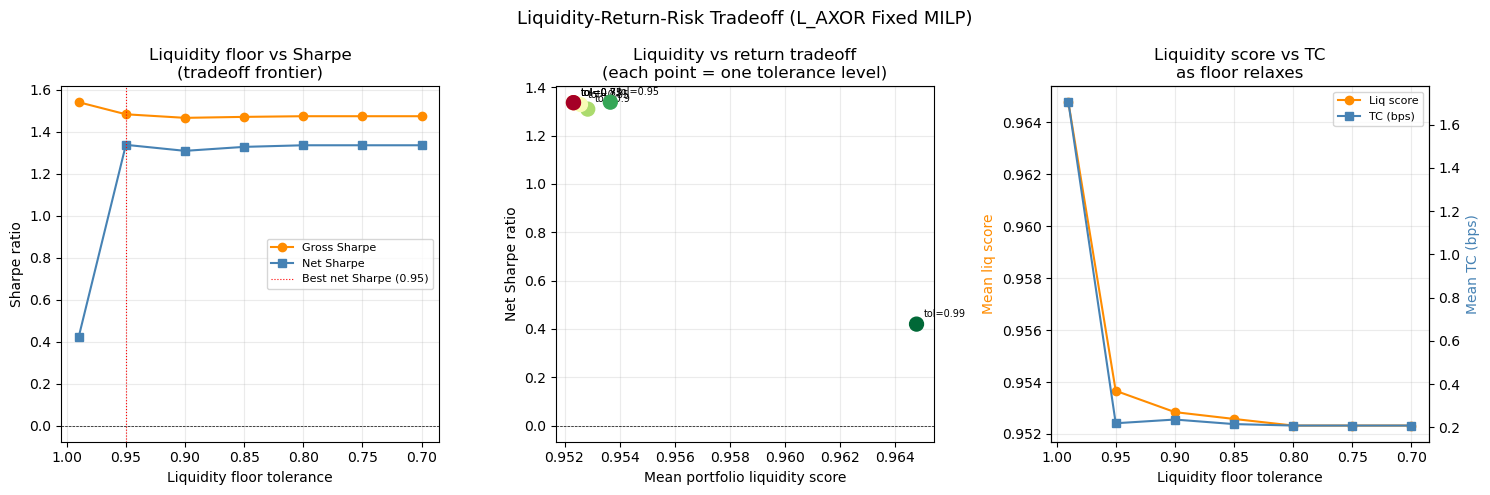


=== TRADEOFF SUMMARY ===
 Tolerance Gross Sharpe Net Sharpe  Liq Score   TC (bps)
      0.99       1.5415     0.4198     0.9648     1.7044
      0.95       1.4837     1.3381     0.9537     0.2196
      0.90       1.4667     1.3094     0.9528     0.2368
      0.85       1.4714     1.3284     0.9526     0.2158
      0.80       1.4745     1.3360     0.9523     0.2090
      0.75       1.4745     1.3360     0.9523     0.2090
      0.70       1.4745     1.3360     0.9523     0.2090

Key finding: optimal liquidity floor = 95%
  At tol=0.99 (tightest): net Sharpe = 0.4198, liq score = 0.9648
  At tol=0.95 (best):     net Sharpe = 1.3381, liq score = 0.9537
  Net Sharpe gained: 0.9183
  Liquidity score given up: 0.0111
  Turnover change: 0.0964 -> 0.0140


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

tols = list(tol_results.keys())
gross_sharpes  = [tol_results[t]["gross_sharpe"]   for t in tols]
net_sharpes    = [tol_results[t]["net_sharpe"]     for t in tols]
liq_scores     = [tol_results[t]["mean_liq_score"] for t in tols]
tcs            = [tol_results[t]["mean_tc"]        for t in tols]

# plot 1: liquidity floor vs Sharpe
ax = axes[0]
ax.plot(tols, gross_sharpes, "o-", color="darkorange", label="Gross Sharpe")
ax.plot(tols, net_sharpes,   "s-", color="steelblue",  label="Net Sharpe")
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
_best_tol = max(tol_results, key=lambda t: tol_results[t]["net_sharpe"])
ax.axvline(_best_tol, color="red", linewidth=0.8, linestyle=":",
           label=f"Best net Sharpe ({_best_tol:.2f})")
ax.set_xlabel("Liquidity floor tolerance")
ax.set_ylabel("Sharpe ratio")
ax.set_title("Liquidity floor vs Sharpe\n(tradeoff frontier)")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
ax.invert_xaxis()  # tighter floor on left

# plot 2: liquidity score vs net Sharpe
ax = axes[1]
ax.scatter(liq_scores, net_sharpes, c=tols, cmap="RdYlGn", s=100, zorder=5)
for t, ls, ns in zip(tols, liq_scores, net_sharpes):
    ax.annotate(f"tol={t}", (ls, ns), textcoords="offset points",
                xytext=(5, 5), fontsize=7)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_xlabel("Mean portfolio liquidity score")
ax.set_ylabel("Net Sharpe ratio")
ax.set_title("Liquidity vs return tradeoff\n(each point = one tolerance level)")
ax.grid(alpha=0.25)

# plot 3: liquidity score vs TC
ax = axes[2]
ax2 = ax.twinx()
ax.plot(tols, liq_scores, "o-", color="darkorange", label="Liq score")
ax2.plot(tols, [t * 1e4 for t in tcs], "s-", color="steelblue", label="TC (bps)")
ax.set_xlabel("Liquidity floor tolerance")
ax.set_ylabel("Mean liq score", color="darkorange")
ax2.set_ylabel("Mean TC (bps)", color="steelblue")
ax.set_title("Liquidity score vs TC\nas floor relaxes")
ax.invert_xaxis()
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax.grid(alpha=0.25)

plt.suptitle("Liquidity-Return-Risk Tradeoff (L_AXOR Fixed MILP)", fontsize=13)
plt.tight_layout()
plt.show()

# summary
print("\n=== TRADEOFF SUMMARY ===")
print(f"{'Tolerance':>10} {'Gross Sharpe':>12} {'Net Sharpe':>10} {'Liq Score':>10} {'TC (bps)':>10}")
for t in tols:
    r = tol_results[t]
    print(f"{t:>10.2f} {r['gross_sharpe']:>12.4f} {r['net_sharpe']:>10.4f} "
          f"{r['mean_liq_score']:>10.4f} {r['mean_tc']*1e4:>10.4f}")

# Read the optimum off the sweep rather than asserting it (the old cell
# hardcoded 95%, which silently stopped being true once the model changed).
_best   = max(tol_results, key=lambda t: tol_results[t]["net_sharpe"])
_tightest = max(tol_results)
print(f"\nKey finding: optimal liquidity floor = {_best:.0%}")
print(f"  At tol={_tightest:.2f} (tightest): net Sharpe = {tol_results[_tightest]['net_sharpe']:.4f}, "
      f"liq score = {tol_results[_tightest]['mean_liq_score']:.4f}")
print(f"  At tol={_best:.2f} (best):     net Sharpe = {tol_results[_best]['net_sharpe']:.4f}, "
      f"liq score = {tol_results[_best]['mean_liq_score']:.4f}")
print(f"  Net Sharpe gained: {tol_results[_best]['net_sharpe'] - tol_results[_tightest]['net_sharpe']:.4f}")
print(f"  Liquidity score given up: "
      f"{tol_results[_tightest]['mean_liq_score'] - tol_results[_best]['mean_liq_score']:.4f}")
print(f"  Turnover change: {tol_results[_tightest]['mean_turnover']:.4f} -> "
      f"{tol_results[_best]['mean_turnover']:.4f}")

## 14. Automation Eligibility Gate D(t)

In [ ]:
# ── D(t) Automation Eligibility Gate ────────────────────────────────

# D(t) = cross-source price disagreement
# using AXOR vs TRACE as the two sources
panel["D_t"] = np.where(
    panel["P_BCQ"].notna(),
    panel[["P_TRACE","P_BCQ","P_AXOR"]].std(axis=1) / panel["P_AXOR"],
    (panel["P_AXOR"] - panel["P_TRACE"]).abs() / panel["P_AXOR"]
)

# add BCQ disagreement where available
panel["D_t_bcq"] = (panel["P_BCQ"] - panel["P_TRACE"]).abs() / panel["P_TRACE"]

print("D(t) stats:")
print(panel["D_t"].describe().round(6))
print(f"\nNaN rate: {panel['D_t'].isna().mean():.1%}")

D(t) stats:
count    3.904712e+06
mean     2.793000e-03
std      1.569500e-02
min      0.000000e+00
25%      3.420000e-04
50%      8.960000e-04
75%      2.203000e-03
max      4.894863e+00
Name: D_t, dtype: float64

NaN rate: 0.0%


In [ ]:
# threshold based on distribution percentiles
print("D(t) percentile analysis:")
for p in [50, 75, 90, 95, 99]:
    val = panel["D_t"].quantile(p/100)
    print(f"  p{p}: {val:.5f} ({val*100:.3f}%)")

print(f"\nCurrent thresholds:")
print(f"  LOW  (automatable): D(t) < 0.005 = {(panel['D_t'] < 0.005).mean():.1%} of bond-days")
print(f"  HIGH (escalate):    D(t) > 0.010 = {(panel['D_t'] > 0.010).mean():.1%} of bond-days")

D(t) percentile analysis:
  p50: 0.00090 (0.090%)
  p75: 0.00220 (0.220%)
  p90: 0.00494 (0.494%)
  p95: 0.00815 (0.815%)
  p99: 0.02403 (2.403%)

Current thresholds:
  LOW  (automatable): D(t) < 0.005 = 90.1% of bond-days
  HIGH (escalate):    D(t) > 0.010 = 3.7% of bond-days


Thresholds set: LOW=0.005, HIGH=0.01
=== AUTOMATION ELIGIBILITY RATE ===
Thresholds: LOW=0.005 (auto), HIGH=0.01 (escalate)

L_AXOR:
  Automation eligibility rate: 79.6%
  Escalation rate:             20.4%
  Mean D(t) on held bonds:     0.00237
  Mean max D(t) on held bonds: 0.02551
  Mean % bonds automatable:    98.9%

L_TRACE_MRR:
  Automation eligibility rate: 53.1%
  Escalation rate:             46.9%
  Mean D(t) on held bonds:     0.00244
  Mean max D(t) on held bonds: 0.03511
  Mean % bonds automatable:    97.5%



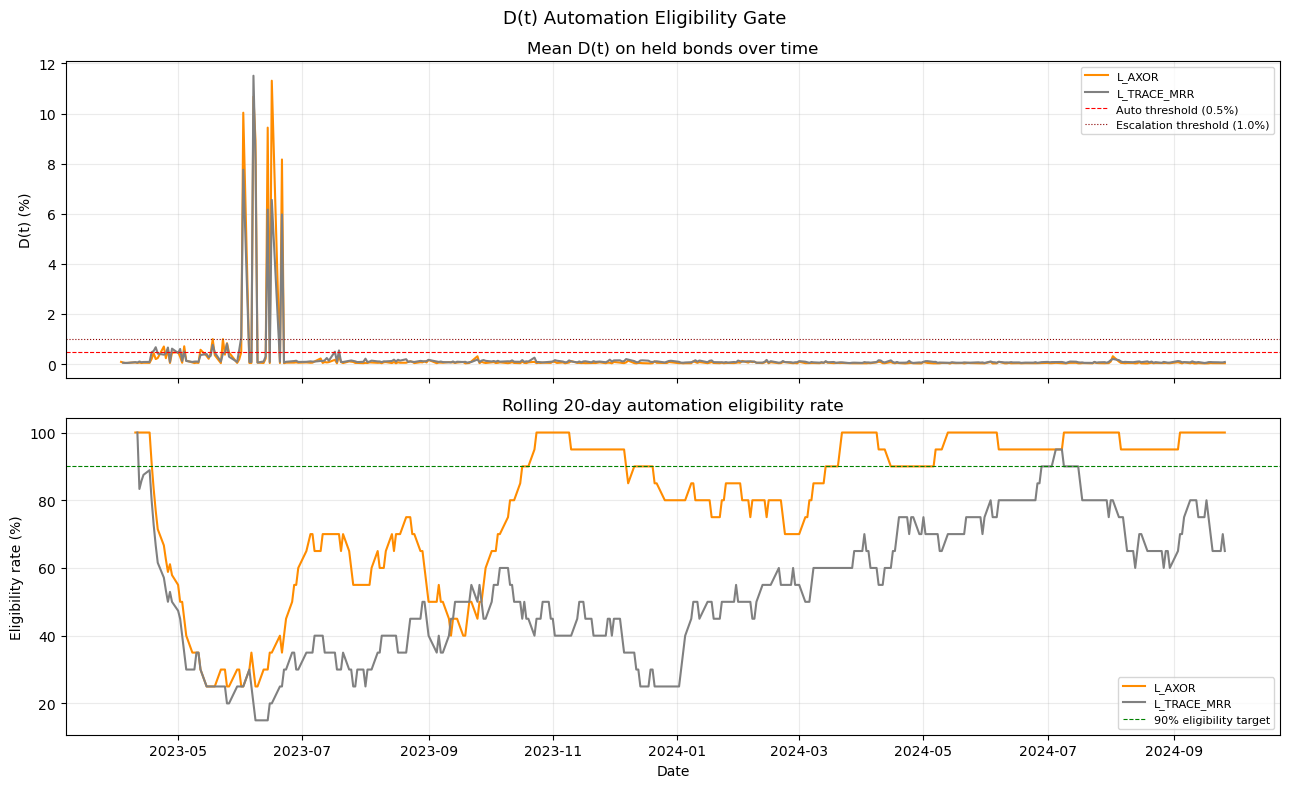

In [ ]:
eligibility_rows = []
D_THRESHOLD_LOW  = 0.005   # below this = automatable (0.5% disagreement)
D_THRESHOLD_HIGH = 0.010   # above this = hard escalation (1% disagreement)
print(f"Thresholds set: LOW={D_THRESHOLD_LOW}, HIGH={D_THRESHOLD_HIGH}")

for sig in ["L_AXOR", "L_TRACE_MRR"]:
    daily_df = milp_results[sig]["daily"].copy()
    daily_df["date"] = pd.to_datetime(daily_df["date"])

    for _, row in daily_df.iterrows():
        date = row["date"]
        day_panel = panel[panel["date"] == date].copy()
        eligible = apply_eligibility(day_panel)
        sub = eligible.dropna(subset=[sig]).reset_index(drop=True)

        if len(sub) == 0:
            continue

        try:
            w_target, _ = solve_stage_a(sub, sig)
        except Exception:
            continue

        held_mask = w_target > 1e-8
        held_bonds = sub[held_mask].copy()
        held_dt = held_bonds["D_t"].dropna()

        if len(held_dt) == 0:
            continue

        mean_dt  = held_dt.mean()
        max_dt   = held_dt.max()
        pct_auto = (held_dt < D_THRESHOLD_LOW).mean()
        automatable = max_dt < D_THRESHOLD_HIGH

        eligibility_rows.append({
            "date":           date,
            "signal":         sig,
            "n_held":         held_mask.sum(),
            "mean_D_t":       mean_dt,
            "max_D_t":        max_dt,
            "pct_bonds_auto": pct_auto,
            "automatable":    automatable,
        })

elig_df = pd.DataFrame(eligibility_rows)

print("=== AUTOMATION ELIGIBILITY RATE ===")
print(f"Thresholds: LOW={D_THRESHOLD_LOW} (auto), HIGH={D_THRESHOLD_HIGH} (escalate)\n")

for sig in ["L_AXOR", "L_TRACE_MRR"]:
    sub = elig_df[elig_df["signal"] == sig]
    rate = sub["automatable"].mean()
    print(f"{sig}:")
    print(f"  Automation eligibility rate: {rate:.1%}")
    print(f"  Escalation rate:             {1-rate:.1%}")
    print(f"  Mean D(t) on held bonds:     {sub['mean_D_t'].mean():.5f}")
    print(f"  Mean max D(t) on held bonds: {sub['max_D_t'].mean():.5f}")
    print(f"  Mean % bonds automatable:    {sub['pct_bonds_auto'].mean():.1%}")
    print()

# plot eligibility over time
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

colors = {"L_AXOR": "darkorange", "L_TRACE_MRR": "gray"}

for sig in ["L_AXOR", "L_TRACE_MRR"]:
    sub = elig_df[elig_df["signal"] == sig].copy()
    sub["date"] = pd.to_datetime(sub["date"])

    # mean D(t) over time
    axes[0].plot(sub["date"], sub["mean_D_t"] * 100,
                 label=sig, color=colors[sig], linewidth=1.5)

    # rolling 20-day automation rate
    sub = sub.sort_values("date")
    rolling_auto = sub["automatable"].rolling(20, min_periods=5).mean()
    axes[1].plot(sub["date"], rolling_auto * 100,
                 label=sig, color=colors[sig], linewidth=1.5)

axes[0].axhline(D_THRESHOLD_LOW * 100, color="red", linewidth=0.8,
                linestyle="--", label=f"Auto threshold ({D_THRESHOLD_LOW*100:.1f}%)")
axes[0].axhline(D_THRESHOLD_HIGH * 100, color="darkred", linewidth=0.8,
                linestyle=":", label=f"Escalation threshold ({D_THRESHOLD_HIGH*100:.1f}%)")
axes[0].set_title("Mean D(t) on held bonds over time")
axes[0].set_ylabel("D(t) (%)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].axhline(90, color="green", linewidth=0.8,
                linestyle="--", label="90% eligibility target")
axes[1].set_title("Rolling 20-day automation eligibility rate")
axes[1].set_ylabel("Eligibility rate (%)")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

plt.suptitle("D(t) Automation Eligibility Gate", fontsize=13)
plt.tight_layout()
plt.show()

## 14b. Liquidity-signal dispersion LD(t)

Complements the D(t) **price** dispersion above with dispersion among the **liquidity signals** themselves (`L_AXOR`, `L_BCQ`, `L_TRACE_MRR`, plus `L_AXOR_D2D` when section 8 was run).

The raw signals live on different scales (price band vs quoted spread vs impact measure), so they are first converted to **cross-sectional percentile ranks per date** (0 = most liquid, 1 = least liquid). Then per bond-day:

`LD(t) = std(rank_L_AXOR, rank_L_BCQ, rank_L_TRACE_MRR, ...)` over the signals available that day (needs ≥ 2).

- **Low LD(t)** — the signals agree on how liquid the bond is.
- **High LD(t)** — the sources disagree (e.g. AXOR says liquid, BondCliQ says illiquid), so any single-signal liquidity score for that bond is less trustworthy.

Signals used: ['L_AXOR', 'L_BCQ', 'L_TRACE_MRR', 'L_AXOR_D2D']

Bond-days with >= 2 signals: 94.4%

LD(t) stats:
count    3.686686e+06
mean     1.344000e-01
std      1.140000e-01
min      0.000000e+00
25%      4.680000e-02
50%      1.057000e-01
75%      1.916000e-01
max      7.059000e-01
Name: LD_t, dtype: float64

LD(t) percentile analysis:
  p50: 0.1057
  p75: 0.1916
  p90: 0.2899
  p95: 0.3606
  p99: 0.5149

Correlation LD(t) vs D(t): 0.038

Pairwise rank correlation between signals:
                  rank_L_AXOR  rank_L_BCQ  rank_L_TRACE_MRR  rank_L_AXOR_D2D
rank_L_AXOR             1.000       0.543             0.641            0.684
rank_L_BCQ              0.543       1.000             0.368            0.476
rank_L_TRACE_MRR        0.641       0.368             1.000            0.545
rank_L_AXOR_D2D         0.684       0.476             0.545            1.000


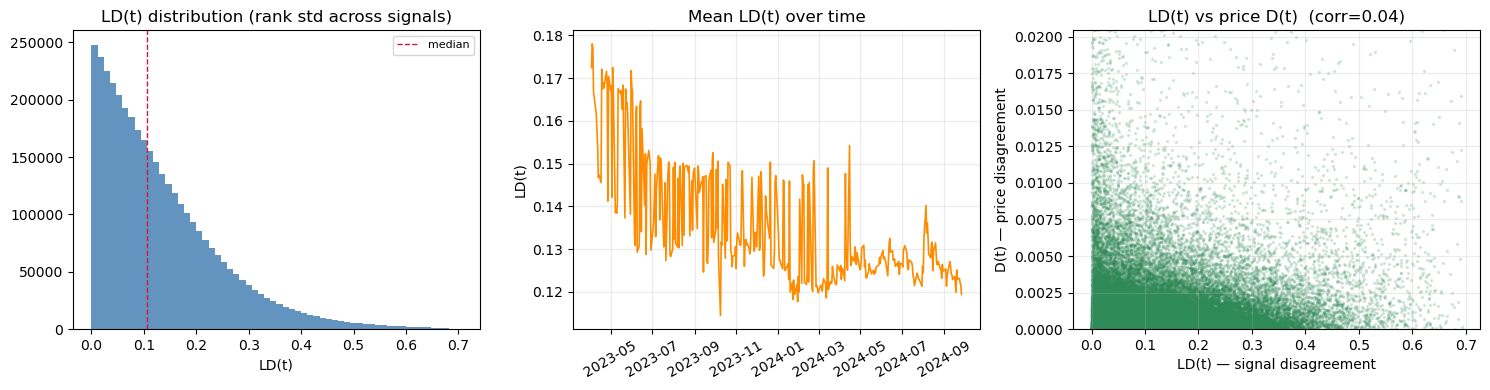

In [ ]:
# ── Liquidity-signal dispersion LD(t) ───────────────────────────────

LD_SIGNALS = [c for c in ["L_AXOR", "L_BCQ", "L_TRACE_MRR", "L_AXOR_D2D"] if c in panel.columns]
print(f"Signals used: {LD_SIGNALS}")

# cross-sectional percentile rank per date (0 = most liquid, 1 = least liquid)
rank_cols = []
for col in LD_SIGNALS:
    rc = f"rank_{col}"
    panel[rc] = panel.groupby("date")[col].rank(pct=True)
    rank_cols.append(rc)

# dispersion across available signal ranks (need >= 2 signals on that bond-day)
n_avail = panel[rank_cols].notna().sum(axis=1)
panel["LD_t"] = panel[rank_cols].std(axis=1, ddof=1).where(n_avail >= 2)

print(f"\nBond-days with >= 2 signals: {(n_avail >= 2).mean():.1%}")
print("\nLD(t) stats:")
print(panel["LD_t"].describe().round(4))

print("\nLD(t) percentile analysis:")
for p in [50, 75, 90, 95, 99]:
    print(f"  p{p}: {panel['LD_t'].quantile(p/100):.4f}")

# how does signal disagreement relate to price disagreement?
corr_ld_dt = panel[["LD_t", "D_t"]].dropna().corr().iloc[0, 1]
print(f"\nCorrelation LD(t) vs D(t): {corr_ld_dt:.3f}")

# pairwise signal-rank agreement (Spearman-style, on the pct ranks)
print("\nPairwise rank correlation between signals:")
print(panel[rank_cols].corr().round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.hist(panel["LD_t"].dropna(), bins=60, color="steelblue", alpha=0.85)
ax.axvline(panel["LD_t"].median(), color="crimson", ls="--", lw=1, label="median")
ax.set_title("LD(t) distribution (rank std across signals)")
ax.set_xlabel("LD(t)")
ax.legend(fontsize=8)

ax = axes[1]
ld_daily = panel.groupby("date")["LD_t"].mean()
ax.plot(pd.to_datetime(ld_daily.index), ld_daily.values, color="darkorange", lw=1.2)
ax.set_title("Mean LD(t) over time")
ax.set_ylabel("LD(t)")
ax.tick_params(axis="x", rotation=30)
ax.grid(alpha=0.25)

ax = axes[2]
_sub = panel[["LD_t", "D_t"]].dropna()
if len(_sub) > 50_000:
    _sub = _sub.sample(50_000, random_state=0)
ax.scatter(_sub["LD_t"], _sub["D_t"], s=2, alpha=0.15, color="seagreen")
ax.set_ylim(0, _sub["D_t"].quantile(0.99))
ax.set_title(f"LD(t) vs price D(t)  (corr={corr_ld_dt:.2f})")
ax.set_xlabel("LD(t) — signal disagreement")
ax.set_ylabel("D(t) — price disagreement")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 15. Cost Efficiency

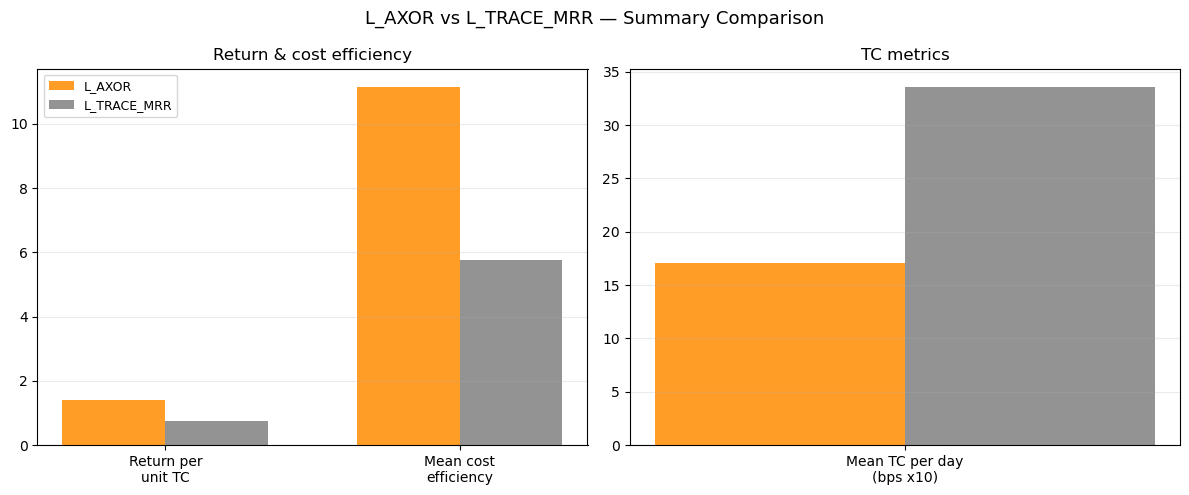

=== COST EFFICIENCY SUMMARY (computed, not hardcoded) ===
Metric                                    L_AXOR  L_TRACE_MRR
Return per unit TC                        1.4167       0.7360
Mean cost efficiency                     11.1624       5.7722
Mean TC per day (bps)                     1.7044       3.3608
Total predicted TC                        0.0632       0.1247
Total realized TC                         0.0752       0.1488


In [ ]:
import matplotlib.dates as mdates
from bond_portfolio_milp import summarize_backtest, compute_cost_efficiency, return_per_unit_tc

# `benchmark` must already exist from the tracking-error cell (equal-weight series)
axor_res = milp_results["L_AXOR"]
mrr_res = milp_results["L_TRACE_MRR"]

rptc_axor = return_per_unit_tc(axor_res["gross"], axor_res["daily"])
rptc_mrr = return_per_unit_tc(mrr_res["gross"], mrr_res["daily"])
ce_axor = compute_cost_efficiency(axor_res["daily"], axor_res["gross"], benchmark)
ce_mrr = compute_cost_efficiency(mrr_res["daily"], mrr_res["gross"], benchmark)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
metrics1 = {
    "Return per\nunit TC": [rptc_axor, rptc_mrr],
    "Mean cost\nefficiency": [ce_axor, ce_mrr],
}
x = np.arange(len(metrics1))
width = 0.35
ax.bar(x - width / 2, [v[0] for v in metrics1.values()], width, label="L_AXOR", color="darkorange", alpha=0.85)
ax.bar(x + width / 2, [v[1] for v in metrics1.values()], width, label="L_TRACE_MRR", color="gray", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(metrics1.keys(), fontsize=10)
ax.set_title("Return & cost efficiency")
ax.legend(fontsize=9)
ax.grid(alpha=0.25, axis="y")

s_axor = summarize_backtest(axor_res["daily"], axor_res["gross"], axor_res["net"])
s_mrr = summarize_backtest(mrr_res["daily"], mrr_res["gross"], mrr_res["net"])

ax = axes[1]
metrics2 = {
    "Mean TC per day\n(bps x10)": [
        s_axor["mean_predicted_tc"] * 1e4 * 10,
        s_mrr["mean_predicted_tc"] * 1e4 * 10,
    ],
}
ax.bar([0 - width / 2], [metrics2["Mean TC per day\n(bps x10)"][0]], width, color="darkorange", alpha=0.85)
ax.bar([0 + width / 2], [metrics2["Mean TC per day\n(bps x10)"][1]], width, color="gray", alpha=0.85)
ax.set_xticks([0])
ax.set_xticklabels(list(metrics2.keys()), fontsize=10)
ax.set_title("TC metrics")
ax.grid(alpha=0.25, axis="y")
plt.suptitle("L_AXOR vs L_TRACE_MRR — Summary Comparison", fontsize=13)
plt.tight_layout()
plt.show()

print("=== COST EFFICIENCY SUMMARY (computed, not hardcoded) ===")
print(f"{'Metric':35} {'L_AXOR':>12} {'L_TRACE_MRR':>12}")
print(f"{'Return per unit TC':35} {rptc_axor:>12.4f} {rptc_mrr:>12.4f}")
print(f"{'Mean cost efficiency':35} {ce_axor:>12.4f} {ce_mrr:>12.4f}")
print(
    f"{'Mean TC per day (bps)':35} "
    f"{s_axor['mean_predicted_tc'] * 1e4:>12.4f} "
    f"{s_mrr['mean_predicted_tc'] * 1e4:>12.4f}"
)
print(f"{'Total predicted TC':35} {s_axor['total_predicted_tc']:>12.4f} {s_mrr['total_predicted_tc']:>12.4f}")
print(f"{'Total realized TC':35} {s_axor['total_realized_tc']:>12.4f} {s_mrr['total_realized_tc']:>12.4f}")


## 16. Trade-List Stability

=== TRADE-LIST STABILITY (JACCARD) ===

L_AXOR:
  Mean Jaccard:     0.2462
  Median Jaccard:   0.2469
  Min Jaccard:      0.0576
  Mean bonds added: 61.3/day
  Mean bonds dropped: 61.3/day

L_TRACE_MRR:
  Mean Jaccard:     0.5319
  Median Jaccard:   0.5303
  Min Jaccard:      0.2785
  Mean bonds added: 31.0/day
  Mean bonds dropped: 31.0/day



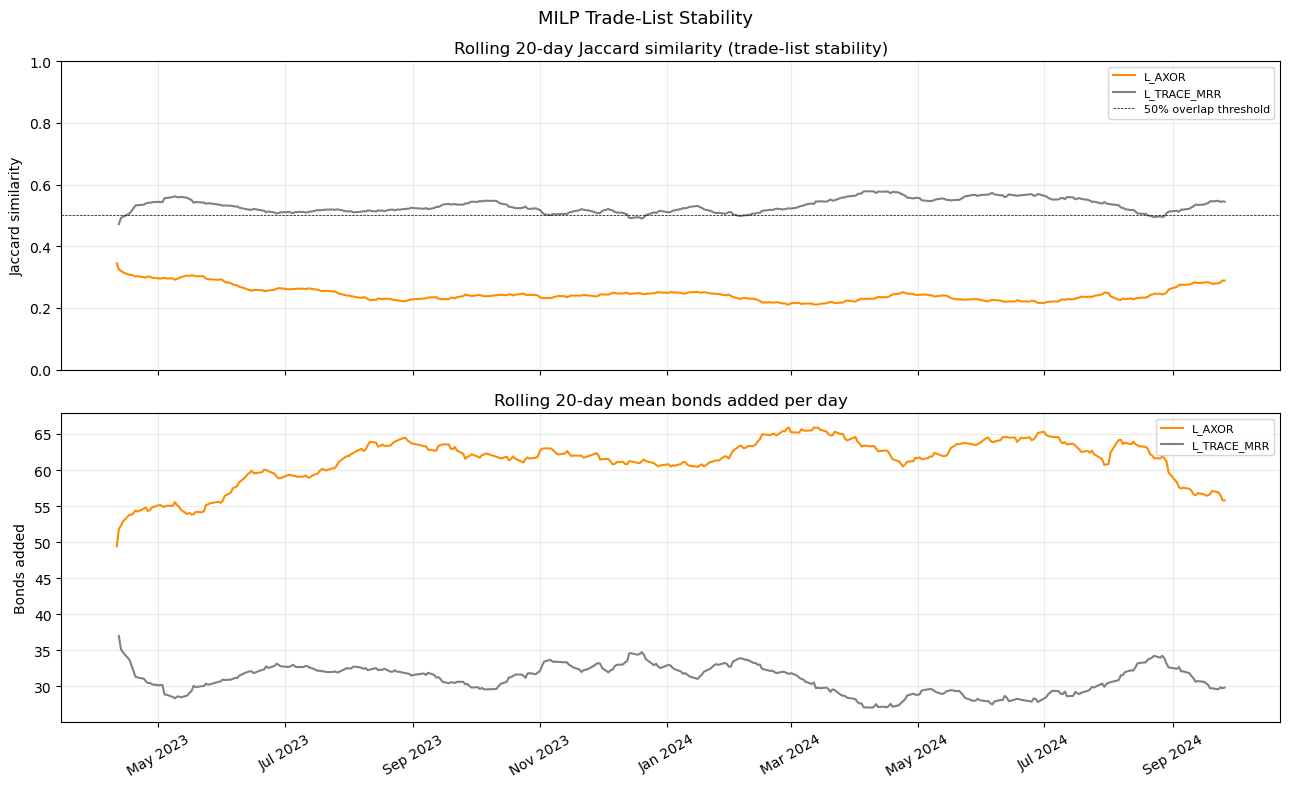

In [ ]:
# ── Trade-list Stability (Jaccard) for MILP ─────────────────────────

jaccard_rows = []

for sig in ["L_AXOR", "L_TRACE_MRR"]:
    daily_df = milp_results[sig]["daily"].copy()
    daily_df["date"] = pd.to_datetime(daily_df["date"])
    dates = sorted(daily_df["date"].unique())

    prev_held = None

    for date in dates:
        day_panel = panel[panel["date"] == date].copy()
        eligible = apply_eligibility(day_panel)
        sub = eligible.dropna(subset=[sig]).reset_index(drop=True)

        if len(sub) == 0:
            continue

        try:
            w_target, _ = solve_stage_a(sub, sig)
        except Exception:
            prev_held = None
            continue

        held_cusips = set(sub["cusip"][w_target > 1e-8].tolist())

        if prev_held is not None and len(held_cusips) > 0 and len(prev_held) > 0:
            intersection = len(held_cusips & prev_held)
            union = len(held_cusips | prev_held)
            jaccard = intersection / union if union > 0 else 0.0

            jaccard_rows.append({
                "date":    date,
                "signal":  sig,
                "jaccard": jaccard,
                "n_held":  len(held_cusips),
                "n_new":   len(held_cusips - prev_held),
                "n_dropped": len(prev_held - held_cusips),
            })

        prev_held = held_cusips

jac_df = pd.DataFrame(jaccard_rows)

print("=== TRADE-LIST STABILITY (JACCARD) ===\n")
for sig in ["L_AXOR", "L_TRACE_MRR"]:
    sub = jac_df[jac_df["signal"] == sig]
    print(f"{sig}:")
    print(f"  Mean Jaccard:     {sub['jaccard'].mean():.4f}")
    print(f"  Median Jaccard:   {sub['jaccard'].median():.4f}")
    print(f"  Min Jaccard:      {sub['jaccard'].min():.4f}")
    print(f"  Mean bonds added: {sub['n_new'].mean():.1f}/day")
    print(f"  Mean bonds dropped: {sub['n_dropped'].mean():.1f}/day")
    print()

# plot
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
colors = {"L_AXOR": "darkorange", "L_TRACE_MRR": "gray"}

# jaccard over time
ax = axes[0]
for sig in ["L_AXOR", "L_TRACE_MRR"]:
    sub = jac_df[jac_df["signal"] == sig].copy()
    sub["date"] = pd.to_datetime(sub["date"])
    sub = sub.sort_values("date")
    rolling = sub.set_index("date")["jaccard"].rolling(20, min_periods=5).mean()
    ax.plot(rolling.index, rolling.values,
            label=sig, color=colors[sig], linewidth=1.5)
ax.axhline(0.5, color="black", linewidth=0.5,
           linestyle="--", label="50% overlap threshold")
ax.set_title("Rolling 20-day Jaccard similarity (trade-list stability)")
ax.set_ylabel("Jaccard similarity")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# bonds added/dropped per day
ax = axes[1]
for sig in ["L_AXOR", "L_TRACE_MRR"]:
    sub = jac_df[jac_df["signal"] == sig].copy()
    sub["date"] = pd.to_datetime(sub["date"])
    sub = sub.sort_values("date")
    rolling_new = sub.set_index("date")["n_new"].rolling(20, min_periods=5).mean()
    ax.plot(rolling_new.index, rolling_new.values,
            label=sig, color=colors[sig], linewidth=1.5)
ax.set_title("Rolling 20-day mean bonds added per day")
ax.set_ylabel("Bonds added")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.suptitle("MILP Trade-List Stability", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from bond_portfolio_milp import summarize_backtest
s_axor = summarize_backtest(milp_results["L_AXOR"]["daily"], milp_results["L_AXOR"]["gross"], 
milp_results["L_AXOR"]["net"])
s_mrr  = summarize_backtest(milp_results["L_TRACE_MRR"]["daily"], milp_results["L_TRACE_MRR"]["gross"], 
milp_results["L_TRACE_MRR"]["net"])
jac_axor = jac_df[jac_df["signal"] == "L_AXOR"]["jaccard"]
jac_mrr  = jac_df[jac_df["signal"] == "L_TRACE_MRR"]["jaccard"]
new_axor = jac_df[jac_df["signal"] == "L_AXOR"]["n_new"]
new_mrr  = jac_df[jac_df["signal"] == "L_TRACE_MRR"]["n_new"]
elig_axor = elig_df[elig_df["signal"] == "L_AXOR"]["automatable"].mean()
elig_mrr  = elig_df[elig_df["signal"] == "L_TRACE_MRR"]["automatable"].mean()
print("=== TRADE-LIST STABILITY SUMMARY (computed, not hardcoded) ===")
print(f"{'Metric':35} {'L_AXOR':>10} {'L_TRACE_MRR':>12}")
print("-" * 70)
print(f"{'Mean Jaccard (bond set stability)':35} {jac_axor.mean():>10.4f} {jac_mrr.mean():>12.4f}")
print(f"{'Mean bonds added/day':35} {new_axor.mean():>10.1f} {new_mrr.mean():>12.1f}")
print(f"{'Weight turnover (from backtest)':35} {s_axor['mean_turnover']:>10.4f} {s_mrr['mean_turnover']:>12.4f}")
print(f"{'Automation eligibility':35} {elig_axor:>10.1%} {elig_mrr:>12.1%}")
print(f"{'Gross Sharpe':35} {s_axor['gross_sharpe']:>10.4f} {s_mrr['gross_sharpe']:>12.4f}")
print(f"{'Net Sharpe':35} {s_axor['net_sharpe']:>10.4f} {s_mrr['net_sharpe']:>12.4f}") 

=== TRADE-LIST STABILITY SUMMARY (computed, not hardcoded) ===
Metric                                  L_AXOR  L_TRACE_MRR
----------------------------------------------------------------------
Mean Jaccard (bond set stability)       0.2462       0.5319
Mean bonds added/day                      61.3         31.0
Weight turnover (from backtest)         0.0964       0.1765
Automation eligibility                   79.6%        53.1%
Gross Sharpe                            1.5415       1.5789
Net Sharpe                              0.4198      -0.6385


## 17. Regime Analysis

=== REGIME ANALYSIS: L_AXOR vs L_TRACE_MRR ===

Hiking (Apr-Jul 2023)
  Metric                        L_AXOR  L_TRACE_MRR
  Gross Sharpe                 -0.7598      -1.0204
  Net Sharpe                   -2.2095      -3.8689
  Cum gross return               -0.01       -0.013
  Cum net return               -0.0276      -0.0477
  Mean turnover                 0.1159       0.2073
  Mean TC (bps)                 2.2183       4.4686
  Eligibility rate              0.4938        0.325

Plateau (Aug-Sep 2023)
  Metric                        L_AXOR  L_TRACE_MRR
  Gross Sharpe                 -2.4134      -2.3959
  Net Sharpe                   -3.4649      -4.4094
  Cum gross return             -0.0149      -0.0152
  Cum net return               -0.0215      -0.0275
  Mean turnover                 0.1051       0.1729
  Mean TC (bps)                 1.5635       2.9423
  Eligibility rate              0.6047       0.4651

Pivot Expectations (Oct 23-Mar 24)
  Metric                        L_AXOR

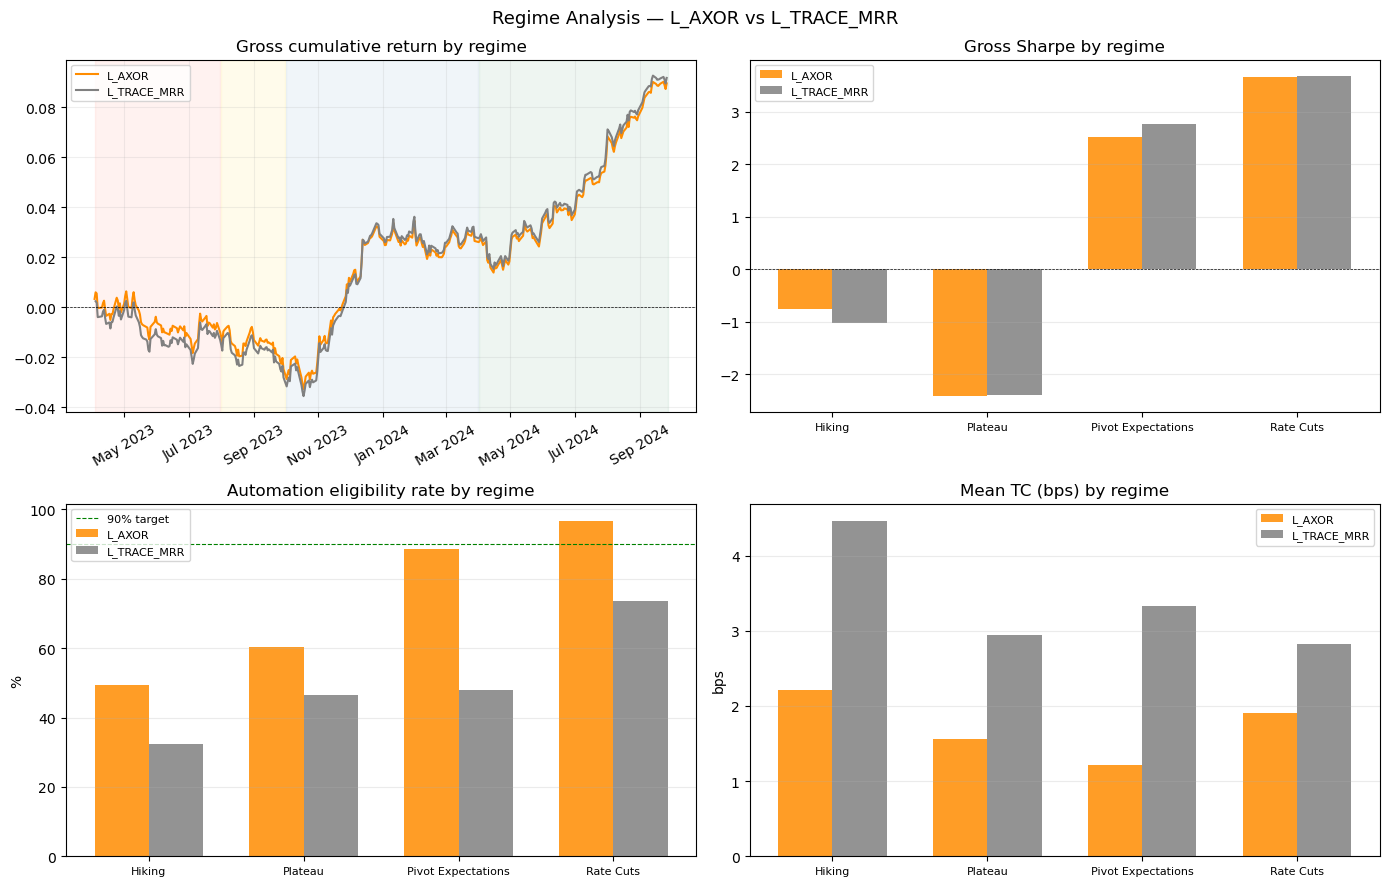

In [ ]:
# ── Regime Analysis ──────────────────────────────────────────────────
# Define four market regimes based on Fed policy cycle

regimes = {
    "Hiking\n(Apr-Jul 2023)":       ("2023-04-03", "2023-07-31"),
    "Plateau\n(Aug-Sep 2023)":      ("2023-08-01", "2023-09-30"),
    "Pivot Expectations\n(Oct 23-Mar 24)": ("2023-10-01", "2024-03-31"),
    "Rate Cuts\n(Apr-Sep 2024)":    ("2024-04-01", "2024-09-27"),
}

print("=== REGIME ANALYSIS: L_AXOR vs L_TRACE_MRR ===\n")
regime_rows = []

for regime_name, (start, end) in regimes.items():
    for sig in ["L_AXOR", "L_TRACE_MRR"]:
        df = milp_results[sig]["daily"].copy()
        df["date"] = pd.to_datetime(df["date"])
        mask = (df["date"] >= start) & (df["date"] <= end)
        sub = df[mask]

        if len(sub) == 0:
            continue

        gross_s = milp_results[sig]["gross"]
        gross_s.index = pd.to_datetime(gross_s.index)
        gross_sub = gross_s[(gross_s.index >= start) & (gross_s.index <= end)]

        net_s = milp_results[sig]["net"]
        net_s.index = pd.to_datetime(net_s.index)
        net_sub = net_s[(net_s.index >= start) & (net_s.index <= end)]

        gs = np.sqrt(252) * gross_sub.mean() / gross_sub.std() if gross_sub.std() > 0 else np.nan
        ns = np.sqrt(252) * net_sub.mean()   / net_sub.std()   if net_sub.std() > 0 else np.nan

        # eligibility rate for this regime
        elig_sub = elig_df[
            (elig_df["signal"] == sig) &
            (pd.to_datetime(elig_df["date"]) >= start) &
            (pd.to_datetime(elig_df["date"]) <= end)
        ]
        elig_rate = elig_sub["automatable"].mean() if len(elig_sub) > 0 else np.nan

        regime_rows.append({
            "regime":        regime_name.replace("\n", " "),
            "signal":        sig,
            "n_days":        len(sub),
            "gross_sharpe":  round(gs, 4),
            "net_sharpe":    round(ns, 4),
            "cum_gross":     round((1+gross_sub).prod()-1, 4),
            "cum_net":       round((1+net_sub).prod()-1, 4),
            "mean_turnover": round(sub["turnover"].mean(), 4),
            "mean_tc_bps":   round(sub["predicted_tc"].mean()*1e4, 4),
            "elig_rate":     round(elig_rate, 4) if not np.isnan(elig_rate) else np.nan,
        })

regime_df = pd.DataFrame(regime_rows)

# print table per regime
for regime_name in [r.replace("\n", " ") for r in regimes.keys()]:
    sub = regime_df[regime_df["regime"] == regime_name]
    axor = sub[sub["signal"] == "L_AXOR"].iloc[0]
    mrr  = sub[sub["signal"] == "L_TRACE_MRR"].iloc[0]
    print(f"{regime_name}")
    print(f"  {'Metric':25} {'L_AXOR':>10} {'L_TRACE_MRR':>12}")
    print(f"  {'Gross Sharpe':25} {axor['gross_sharpe']:>10} {mrr['gross_sharpe']:>12}")
    print(f"  {'Net Sharpe':25} {axor['net_sharpe']:>10} {mrr['net_sharpe']:>12}")
    print(f"  {'Cum gross return':25} {axor['cum_gross']:>10} {mrr['cum_gross']:>12}")
    print(f"  {'Cum net return':25} {axor['cum_net']:>10} {mrr['cum_net']:>12}")
    print(f"  {'Mean turnover':25} {axor['mean_turnover']:>10} {mrr['mean_turnover']:>12}")
    print(f"  {'Mean TC (bps)':25} {axor['mean_tc_bps']:>10} {mrr['mean_tc_bps']:>12}")
    print(f"  {'Eligibility rate':25} {axor['elig_rate']:>10} {mrr['elig_rate']:>12}")
    print()

# plot
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
colors = {"L_AXOR": "darkorange", "L_TRACE_MRR": "gray"}
regime_colors = {
    "Hiking\n(Apr-Jul 2023)":             "tomato",
    "Plateau\n(Aug-Sep 2023)":            "gold",
    "Pivot Expectations\n(Oct 23-Mar 24)": "steelblue",
    "Rate Cuts\n(Apr-Sep 2024)":          "seagreen",
}

# gross cumulative return with regime shading
ax = axes[0, 0]
for sig in ["L_AXOR", "L_TRACE_MRR"]:
    cum = (1 + milp_results[sig]["gross"]).cumprod() - 1
    cum.index = pd.to_datetime(cum.index)
    ax.plot(cum.index, cum.values, label=sig, color=colors[sig], linewidth=1.5)
for regime_name, (start, end) in regimes.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.08, color=regime_colors[regime_name])
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_title("Gross cumulative return by regime")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# gross sharpe by regime
ax = axes[0, 1]
regime_labels = [r.replace("\n", " ") for r in regimes.keys()]
x = np.arange(len(regime_labels))
width = 0.35
ax.bar(x - width/2,
       [regime_df[(regime_df["regime"]==r) & (regime_df["signal"]=="L_AXOR")]["gross_sharpe"].values[0]
        for r in regime_labels],
       width, label="L_AXOR", color="darkorange", alpha=0.85)
ax.bar(x + width/2,
       [regime_df[(regime_df["regime"]==r) & (regime_df["signal"]=="L_TRACE_MRR")]["gross_sharpe"].values[0]
        for r in regime_labels],
       width, label="L_TRACE_MRR", color="gray", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([r.split("(")[0].strip() for r in regime_labels], fontsize=8)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_title("Gross Sharpe by regime")
ax.legend(fontsize=8)
ax.grid(alpha=0.25, axis="y")

# eligibility rate by regime
ax = axes[1, 0]
ax.bar(x - width/2,
       [regime_df[(regime_df["regime"]==r) & (regime_df["signal"]=="L_AXOR")]["elig_rate"].values[0]*100
        for r in regime_labels],
       width, label="L_AXOR", color="darkorange", alpha=0.85)
ax.bar(x + width/2,
       [regime_df[(regime_df["regime"]==r) & (regime_df["signal"]=="L_TRACE_MRR")]["elig_rate"].values[0]*100
        for r in regime_labels],
       width, label="L_TRACE_MRR", color="gray", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([r.split("(")[0].strip() for r in regime_labels], fontsize=8)
ax.axhline(90, color="green", linewidth=0.8, linestyle="--", label="90% target")
ax.set_title("Automation eligibility rate by regime")
ax.set_ylabel("%")
ax.legend(fontsize=8)
ax.grid(alpha=0.25, axis="y")

# TC by regime
ax = axes[1, 1]
ax.bar(x - width/2,
       [regime_df[(regime_df["regime"]==r) & (regime_df["signal"]=="L_AXOR")]["mean_tc_bps"].values[0]
        for r in regime_labels],
       width, label="L_AXOR", color="darkorange", alpha=0.85)
ax.bar(x + width/2,
       [regime_df[(regime_df["regime"]==r) & (regime_df["signal"]=="L_TRACE_MRR")]["mean_tc_bps"].values[0]
        for r in regime_labels],
       width, label="L_TRACE_MRR", color="gray", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([r.split("(")[0].strip() for r in regime_labels], fontsize=8)
ax.set_title("Mean TC (bps) by regime")
ax.set_ylabel("bps")
ax.legend(fontsize=8)
ax.grid(alpha=0.25, axis="y")

plt.suptitle("Regime Analysis — L_AXOR vs L_TRACE_MRR", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── Tracking Error vs Equal-Weight Benchmark ─────────────────────────

# benchmark = equal weight across all eligible bonds each day
# FIX 8: benchmark on the same total-return basis as the portfolio, otherwise
# alpha is a total-return portfolio measured against a price-only benchmark.
_bm_col = RETURN_COL if RETURN_COL in panel.columns else "next_return"
bm = panel.dropna(subset=[_bm_col]).copy()
q01, q99 = bm[_bm_col].quantile([0.01, 0.99])
bm[_bm_col] = bm[_bm_col].clip(q01, q99)
benchmark = bm.groupby("date")[_bm_col].mean()
benchmark.index = pd.to_datetime(benchmark.index)

print("=== TRACKING ERROR vs EQUAL-WEIGHT BENCHMARK ===\n")
te_rows = []

for sig in ["L_AXOR", "L_TRACE_MRR"]:
    gross_s = milp_results[sig]["gross"].copy()
    gross_s.index = pd.to_datetime(gross_s.index)

    common = gross_s.index.intersection(benchmark.index)
    active = gross_s.loc[common] - benchmark.loc[common]

    ann_te     = active.std() * np.sqrt(252)
    ann_alpha  = active.mean() * 252
    info_ratio = ann_alpha / ann_te if ann_te > 0 else np.nan
    max_dd     = (gross_s.loc[common] - gross_s.loc[common].cummax()).min()
    cum_active = (1 + active).prod() - 1

    te_rows.append({
        "signal":          sig,
        "ann_tracking_error": round(ann_te, 6),
        "ann_alpha":       round(ann_alpha, 6),
        "information_ratio": round(info_ratio, 4),
        "max_drawdown":    round(max_dd, 6),
        "cum_active_return": round(cum_active, 6),
        "n_days":          len(common),
    })

    print(f"{sig}:")
    print(f"  Ann. tracking error:   {ann_te:.6f} ({ann_te*100:.4f}%)")
    print(f"  Ann. alpha:            {ann_alpha:.6f} ({ann_alpha*100:.4f}%)")
    print(f"  Information ratio:     {info_ratio:.4f}")
    print(f"  Max drawdown:          {max_dd:.6f}")
    print(f"  Cum. active return:    {cum_active:.6f}")
    print()

te_df = pd.DataFrame(te_rows)

=== TRACKING ERROR vs EQUAL-WEIGHT BENCHMARK ===

L_AXOR:
  Ann. tracking error:   0.018734 (1.8734%)
  Ann. alpha:            -0.080035 (-8.0035%)
  Information ratio:     -4.2723
  Max drawdown:          -0.016249
  Cum. active return:    -0.111398

L_TRACE_MRR:
  Ann. tracking error:   0.018104 (1.8104%)
  Ann. alpha:            -0.076033 (-7.6033%)
  Information ratio:     -4.1999
  Max drawdown:          -0.016706
  Cum. active return:    -0.106131



=== CONSTRAINT VIOLATIONS ===

L_AXOR:
  Bond cap violations   — before: 69.29/day,   after: 0.00/day
  Issuer cap violations — before: 0.70/day, after: 0.00/day
  Sector cap violations — before: 0.22/day, after: 0.00/day
  Total violations      — before: 70.21/day, after: 0.00/day
  Days with any violation before: 79.2%
  Days with any violation after:  0.0%

L_TRACE_MRR:
  Bond cap violations   — before: 87.69/day,   after: 0.00/day
  Issuer cap violations — before: 0.17/day, after: 0.00/day
  Sector cap violations — before: 0.24/day, after: 0.00/day
  Total violations      — before: 88.09/day, after: 0.00/day
  Days with any violation before: 96.8%
  Days with any violation after:  0.0%



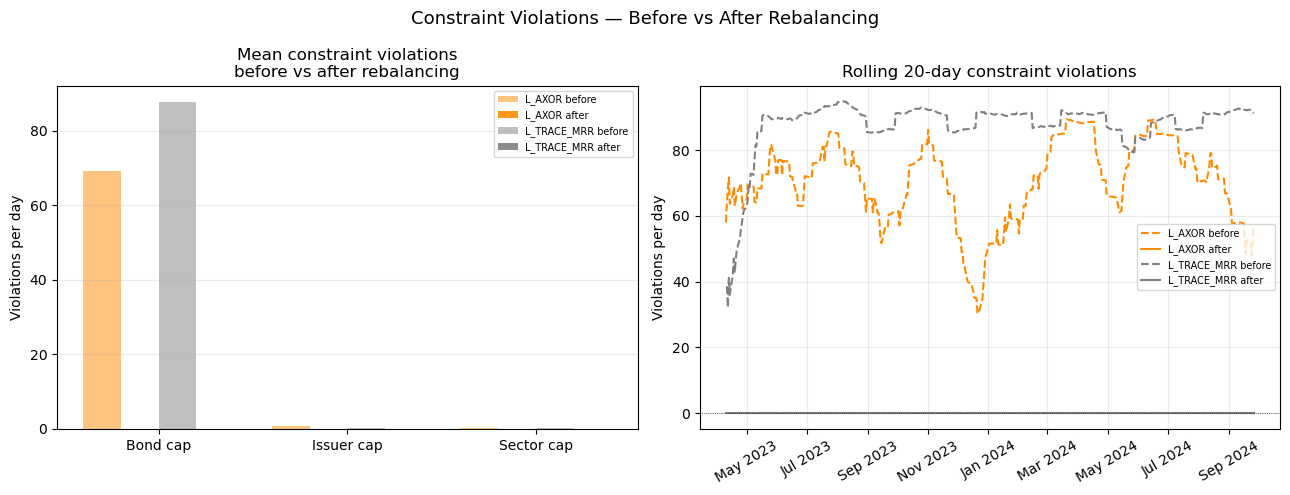

In [ ]:
# ── Constraint Violations ────────────────────────────────────────────
# Check how often the MILP portfolio violates constraints
# before rebalancing (w0) vs after rebalancing (w_final)

violation_rows = []

for sig in ["L_AXOR", "L_TRACE_MRR"]:
    daily_df = milp_results[sig]["daily"].copy()
    daily_df["date"] = pd.to_datetime(daily_df["date"])
    dates = sorted(daily_df["date"].unique())

    port_w = None
    port_cusips = None

    for date in dates:
        day_panel = panel[panel["date"] == date].copy()
        eligible = apply_eligibility(day_panel)
        sub = eligible.dropna(subset=[sig]).reset_index(drop=True)

        if len(sub) == 0:
            continue

        try:
            w_target, meta_a = solve_stage_a(sub, sig)
        except Exception:
            continue

        # map previous weights to current universe
        if port_w is None:
            w0 = np.zeros(len(sub))
        else:
            prev_series = pd.Series(port_w, index=port_cusips)
            w0 = sub["cusip"].map(prev_series).fillna(0.0).to_numpy(float)
            if w0.sum() > 0:
                w0 = w0 / w0.sum()

        try:
            w_final, meta_b = solve_stage_b(sub, w0, meta_a["objective_liq_score"], sig)
        except Exception:
            continue

        # check violations BEFORE rebalancing (w0)
        issuers = sub["issuer_name"].fillna("UNKNOWN").astype(str)
        sectors = sub["sector"].fillna("UNKNOWN").astype(str)

        def check_violations(w, policy=POLICY):
            violations = {}
            # bond cap
            violations["bond_cap"] = int((w > policy["max_weight_single_bond"] + 1e-6).sum())
            # issuer cap
            issuer_viol = 0
            for _, idx in sub.groupby(issuers).groups.items():
                if w[list(idx)].sum() > policy["max_weight_single_issuer"] + 1e-6:
                    issuer_viol += 1
            violations["issuer_cap"] = issuer_viol
            # sector cap
            sector_viol = 0
            for _, idx in sub.groupby(sectors).groups.items():
                if w[list(idx)].sum() > policy["max_weight_single_sector"] + 1e-6:
                    sector_viol += 1
            violations["sector_cap"] = sector_viol
            return violations

        v_before = check_violations(w0)
        v_after  = check_violations(w_final)

        violation_rows.append({
            "date":                   date,
            "signal":                 sig,
            "bond_cap_before":        v_before["bond_cap"],
            "bond_cap_after":         v_after["bond_cap"],
            "issuer_cap_before":      v_before["issuer_cap"],
            "issuer_cap_after":       v_after["issuer_cap"],
            "sector_cap_before":      v_before["sector_cap"],
            "sector_cap_after":       v_after["sector_cap"],
            "total_violations_before": sum(v_before.values()),
            "total_violations_after":  sum(v_after.values()),
        })

        port_w = w_final
        port_cusips = sub["cusip"].tolist()

viol_df = pd.DataFrame(violation_rows)

print("=== CONSTRAINT VIOLATIONS ===\n")
for sig in ["L_AXOR", "L_TRACE_MRR"]:
    sub = viol_df[viol_df["signal"] == sig]
    print(f"{sig}:")
    print(f"  Bond cap violations   — before: {sub['bond_cap_before'].mean():.2f}/day,   after: {sub['bond_cap_after'].mean():.2f}/day")
    print(f"  Issuer cap violations — before: {sub['issuer_cap_before'].mean():.2f}/day, after: {sub['issuer_cap_after'].mean():.2f}/day")
    print(f"  Sector cap violations — before: {sub['sector_cap_before'].mean():.2f}/day, after: {sub['sector_cap_after'].mean():.2f}/day")
    print(f"  Total violations      — before: {sub['total_violations_before'].mean():.2f}/day, after: {sub['total_violations_after'].mean():.2f}/day")
    print(f"  Days with any violation before: {(sub['total_violations_before'] > 0).mean():.1%}")
    print(f"  Days with any violation after:  {(sub['total_violations_after'] > 0).mean():.1%}")
    print()

# plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {"L_AXOR": "darkorange", "L_TRACE_MRR": "gray"}

# violations before vs after
ax = axes[0]
categories = ["Bond cap", "Issuer cap", "Sector cap"]
x = np.arange(len(categories))
width = 0.2

for j, sig in enumerate(["L_AXOR", "L_TRACE_MRR"]):
    sub = viol_df[viol_df["signal"] == sig]
    before = [sub["bond_cap_before"].mean(),
              sub["issuer_cap_before"].mean(),
              sub["sector_cap_before"].mean()]
    after  = [sub["bond_cap_after"].mean(),
              sub["issuer_cap_after"].mean(),
              sub["sector_cap_after"].mean()]

    offset = j * 2 * width - width
    ax.bar(x + offset,          before, width, color=colors[sig], alpha=0.5,
           label=f"{sig} before")
    ax.bar(x + offset + width,  after,  width, color=colors[sig], alpha=0.9,
           label=f"{sig} after")

ax.set_xticks(x + width/2)
ax.set_xticklabels(categories)
ax.set_title("Mean constraint violations\nbefore vs after rebalancing")
ax.set_ylabel("Violations per day")
ax.legend(fontsize=7)
ax.grid(alpha=0.25, axis="y")

# total violations over time
ax = axes[1]
for sig in ["L_AXOR", "L_TRACE_MRR"]:
    sub = viol_df[viol_df["signal"] == sig].copy()
    sub["date"] = pd.to_datetime(sub["date"])
    sub = sub.sort_values("date")
    rolling = sub.set_index("date")["total_violations_before"].rolling(20, min_periods=5).mean()
    ax.plot(rolling.index, rolling.values,
            label=f"{sig} before", color=colors[sig],
            linewidth=1.5, linestyle="--")
    rolling_after = sub.set_index("date")["total_violations_after"].rolling(20, min_periods=5).mean()
    ax.plot(rolling_after.index, rolling_after.values,
            label=f"{sig} after", color=colors[sig], linewidth=1.5)

ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax.set_title("Rolling 20-day constraint violations")
ax.set_ylabel("Violations per day")
ax.legend(fontsize=7)
ax.grid(alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.suptitle("Constraint Violations — Before vs After Rebalancing", fontsize=13)
plt.tight_layout()
plt.show()



In [ ]:
panel.to_parquet("panel_project8_extended.parquet", index=False)
print(f"Saved: {panel.shape}")

Saved: (3904712, 44)


In [ ]:
# load updated panel with D2D and create hybrid signal
from pathlib import Path

_parquet_path = Path("panel_project8_extended.parquet")
if "L_AXOR_D2D" not in getattr(panel, "columns", []):
    if _parquet_path.exists():
        panel = pd.read_parquet(_parquet_path)
        panel["date"] = pd.to_datetime(panel["date"])
    else:
        raise FileNotFoundError(
            f"{_parquet_path} not found. Run section 8 (D2D fetch + merge) first."
        )

if "L_AXOR_D2D" not in panel.columns:
    raise KeyError(
        "L_AXOR_D2D still missing after reload. Re-run section 8 D2D fetch + merge cells."
    )
if "L_AXOR" not in panel.columns:
    raise KeyError("L_AXOR missing from panel — re-run panel build (section 2).")

panel["L_AXOR_D2D_filled"] = panel["L_AXOR_D2D"].fillna(panel["L_AXOR"])
print(f"Panel reloaded: {panel.shape}")
print(f"L_AXOR_D2D_filled coverage: {panel['L_AXOR_D2D_filled'].notna().mean():.1%}")
print(f"Bonds with raw D2D: {panel.loc[panel['L_AXOR_D2D'].notna(), 'cusip'].nunique():,}")



Panel reloaded: (3904712, 45)
L_AXOR_D2D_filled coverage: 100.0%
Bonds with raw D2D: 1,274


## 18. Save All Results

In [ ]:
# ── Save all results ────────────────────────────────────────────────
from pathlib import Path
BASE = Path(".")

# save panel (includes L_AXOR_D2D / L_AXOR_D2D_filled when section 8 was run)
panel.to_parquet(BASE / "panel_project8_extended.parquet", index=False)
print(f"Saved: {panel.shape} -> {BASE / 'panel_project8_extended.parquet'}")



Saved: (3904712, 45) -> panel_project8_extended.parquet
